# Idea-Level Analysis

This release notebook keeps only the idea-level analyses that support the manuscript.

Included here:
- Main human vs. LLM comparisons
- Best-idea and top-10 analyses
- Discussion-structure effects by model
- Persona and team-size checks referenced in the paper
- Appendix-ready tables tied to the manuscript

Exploratory comparisons and unused side analyses from the working notebook were removed.


In [ ]:
from pathlib import Path
import os
import glob
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

CANDIDATES = [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd() / 'code_release',
    Path.cwd().parent / 'code_release',
]
RELEASE_ROOT = next((p for p in CANDIDATES if (p / 'data').exists()), None)
if RELEASE_ROOT is None:
    raise FileNotFoundError('Could not find data/ from the current working directory.')

DATA_DIR = RELEASE_ROOT / 'data'
OUTPUT_DIR = RELEASE_ROOT / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)
os.chdir(OUTPUT_DIR)

filtered_merged = pd.read_csv(DATA_DIR / 'ideas_with_ratings_clean.csv')
filtered_merged['question_id'] = filtered_merged['question_id'].astype(str)

human_written_data_df = filtered_merged[filtered_merged['source'] == 'human_data'].copy()
llm_written_data_df = filtered_merged[filtered_merged['source'] != 'human_data'].copy()

task_order = sorted(filtered_merged['question_id'].dropna().astype(str).unique())
task_markers = {task: None for task in task_order}
task_labels = {task: task.replace('_', ' ').title() for task in task_order}
np.random.seed(42)

print(f'Loaded {len(filtered_merged):,} ideas from {DATA_DIR}')
print(f'Human ideas: {len(human_written_data_df):,}')
print(f'LLM ideas: {len(llm_written_data_df):,}')


## Main Performance

Produces Figure 1A (`llm_vs_human_creativity_boxplots.png`) and Figure 1B (`novelty_usefulness_tradeoff.png`).


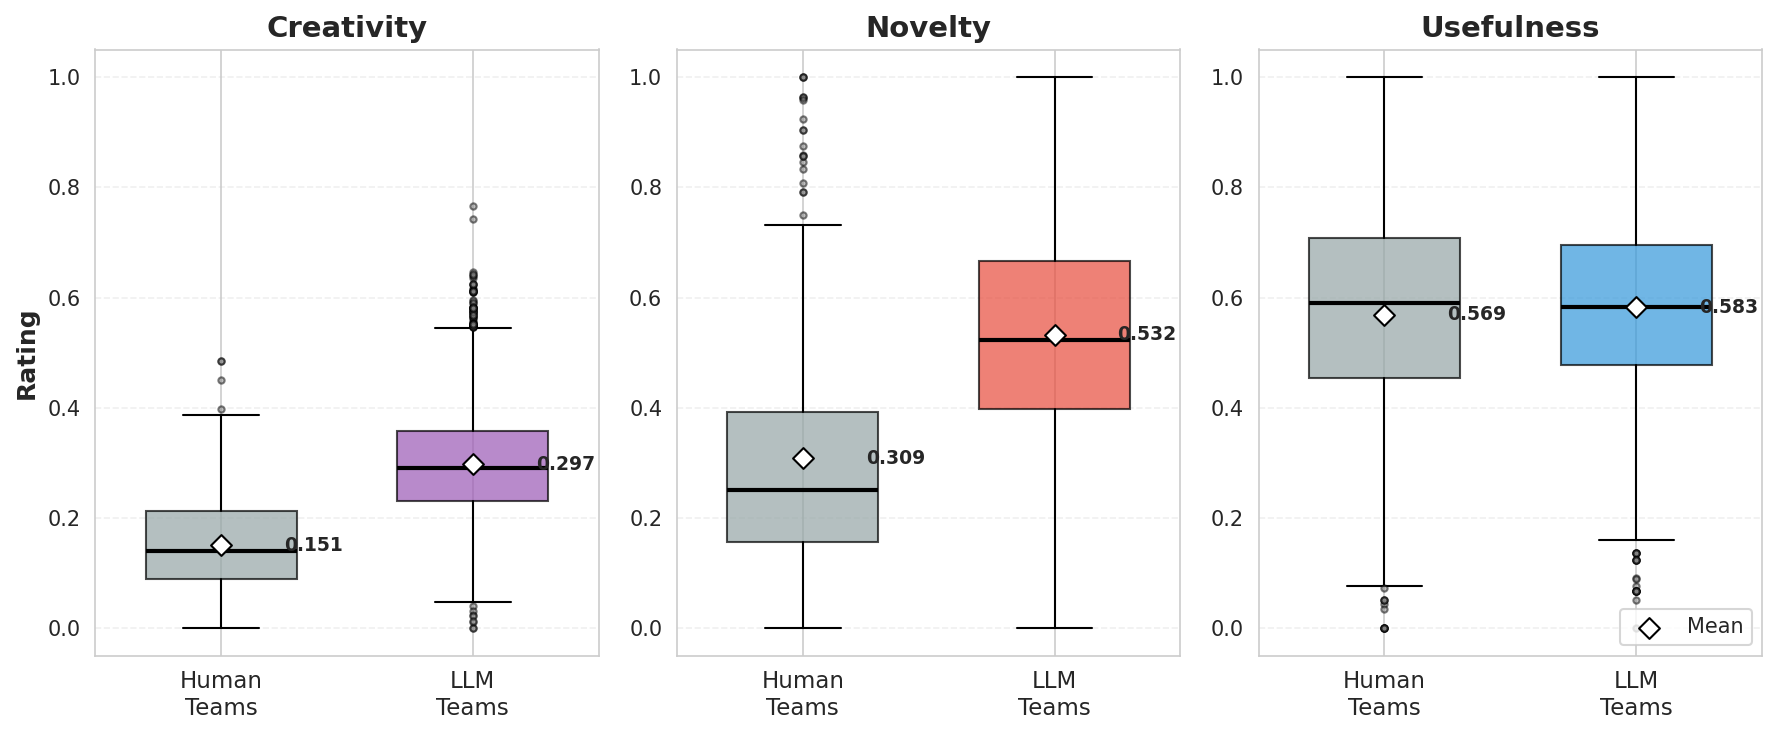

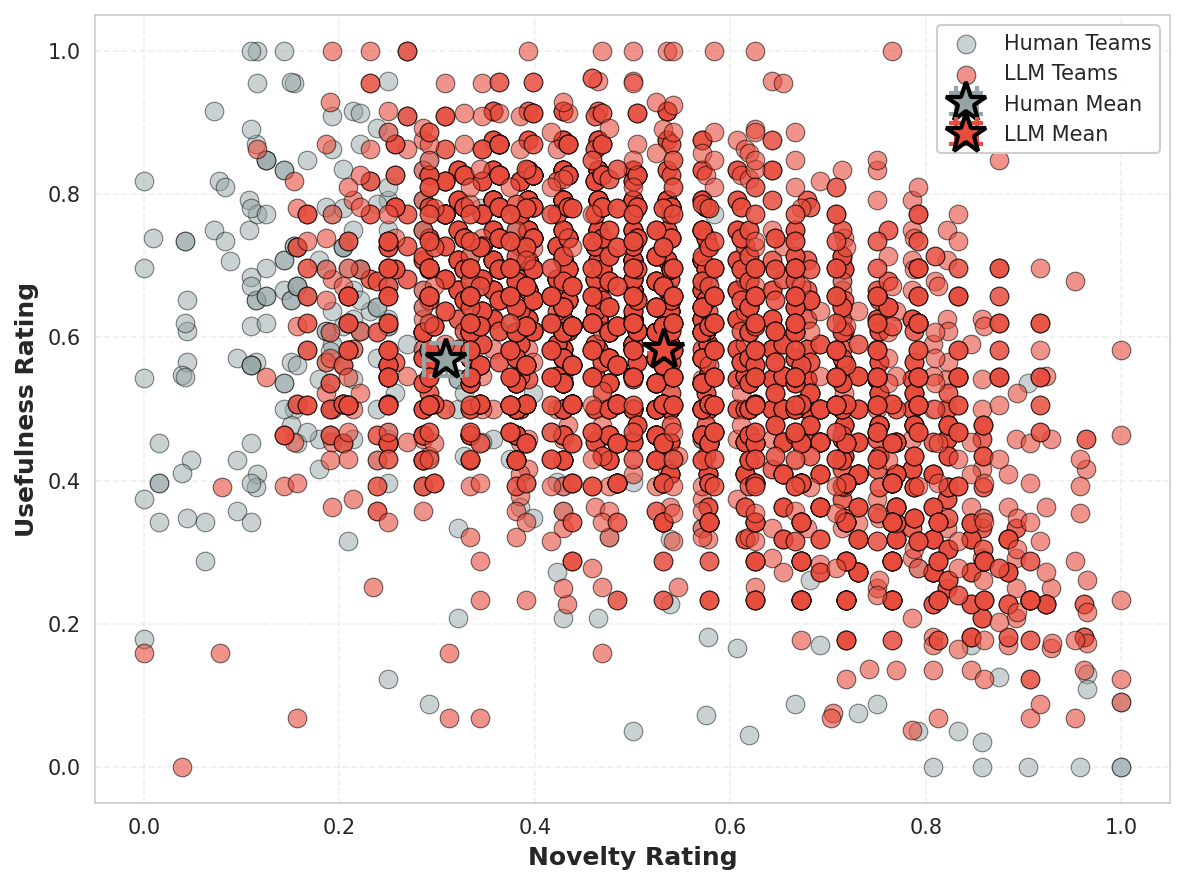

In [113]:
import matplotlib.pyplot as plt
import numpy as np

# Define consistent style parameters
COLORS = {
    'creativity': '#9B59B6',
    'novelty': '#E74C3C', 
    'usefulness': '#3498DB',
    'human': '#95A5A6',
    'llm': '#E74C3C'
}

FONT_SIZES = {
    'title': 14,
    'label': 12,
    'tick': 11,
    'legend': 10,
    'annotation': 9
}

# Filter data
human_nominal = human_written_data_df
llm_multiagent = llm_written_data_df[llm_written_data_df['number_of_agents'] > 1]

# ============================================================================
# Individual Plot 1: Three Box Plots (Creativity, Novelty, Usefulness)
# ============================================================================
fig1, axes = plt.subplots(1, 3, figsize=(12, 5))

dimensions = [
    ('avg_creativity_rating', 'Creativity', COLORS['creativity']),
    ('avg_novelty_rating', 'Novelty', COLORS['novelty']),
    ('avg_usefulness_rating', 'Usefulness', COLORS['usefulness'])
]

for ax, (col, title, color) in zip(axes, dimensions):
    # Prepare data for boxplot
    human_data = human_nominal[col].dropna()
    llm_data = llm_multiagent[col].dropna()
    
    # Create boxplot
    bp = ax.boxplot([human_data, llm_data], 
                    labels=['Human\nTeams', 'LLM\nTeams'],
                    patch_artist=True,
                    widths=0.6,
                    showfliers=True,
                    flierprops=dict(marker='o', markerfacecolor='gray', 
                                   markersize=3, alpha=0.5))
    
    # Color the boxes
    bp['boxes'][0].set_facecolor(COLORS['human'])
    bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_facecolor(color)
    bp['boxes'][1].set_alpha(0.7)
    
    # Style median lines
    for median in bp['medians']:
        median.set_color('black')
        median.set_linewidth(2)
    
    # Style whiskers and caps
    for whisker in bp['whiskers']:
        whisker.set_color('black')
        whisker.set_linewidth(1)
    for cap in bp['caps']:
        cap.set_color('black')
        cap.set_linewidth(1)
    
    # Add mean markers
    means = [human_data.mean(), llm_data.mean()]
    ax.scatter([1, 2], means, marker='D', color='white', 
               edgecolors='black', s=50, zorder=5, label='Mean')
    
    # Add mean annotations
    for i, (pos, mean) in enumerate(zip([1, 2], means)):
        ax.annotate(f'{mean:.3f}', xy=(pos, mean), 
                   xytext=(pos + 0.25, mean),
                   fontsize=FONT_SIZES['annotation'], fontweight='bold',
                   va='center')
    
    ax.set_title(title, fontweight='bold', fontsize=FONT_SIZES['title'])
    ax.set_ylabel('Rating' if ax == axes[0] else '', 
                  fontweight='bold', fontsize=FONT_SIZES['label'])
    ax.grid(True, alpha=0.3, axis='y', linestyle='--')
    ax.tick_params(axis='x', labelsize=FONT_SIZES['tick'])
    
    # Set consistent y-axis
    ax.set_ylim(-0.05, 1.05)

# Add legend for mean marker (only once)
axes[2].legend(loc='lower right', fontsize=FONT_SIZES['legend'])

plt.tight_layout()
plt.savefig('llm_vs_human_creativity_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# Individual Plot 2: Scatter Plot (unchanged)
# ============================================================================
fig2, ax = plt.subplots(figsize=(8, 6))

ax.scatter(human_nominal['avg_novelty_rating'],
          human_nominal['avg_usefulness_rating'],
          alpha=0.5, s=80, color=COLORS['human'],
          edgecolors='black', linewidth=0.5,
          label=f'Human Teams')

ax.scatter(llm_multiagent['avg_novelty_rating'],
          llm_multiagent['avg_usefulness_rating'],
          alpha=0.6, s=80, color=COLORS['llm'],
          edgecolors='black', linewidth=0.5,
          label=f'LLM Teams')

for data, color, label in [
    (human_nominal, COLORS['human'], 'Human Mean'),
    (llm_multiagent, COLORS['llm'], 'LLM Mean')
]:
    ax.errorbar(data['avg_novelty_rating'].mean(),
               data['avg_usefulness_rating'].mean(),
               xerr=data['avg_novelty_rating'].sem() * 1.96,
               yerr=data['avg_usefulness_rating'].sem() * 1.96,
               fmt='*', markersize=20, color=color,
               markeredgecolor='black', markeredgewidth=2,
               capsize=8, capthick=2,
               label=label, zorder=10)

ax.set_xlabel('Novelty Rating', fontweight='bold', fontsize=FONT_SIZES['label'])
ax.set_ylabel('Usefulness Rating', fontweight='bold', fontsize=FONT_SIZES['label'])
ax.legend(loc='best', fontsize=FONT_SIZES['legend'], framealpha=0.95)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('novelty_usefulness_tradeoff.png', dpi=300, bbox_inches='tight')
plt.show()

### Statistical Comparison

Supports the main human-vs-LLM performance claims.


In [114]:
from scipy import stats
import numpy as np
import pandas as pd

# ============================================================================
# DATA PREPARATION
# ============================================================================

# Filter data - define human_nominal and llm_multiagent
human_nominal = human_written_data_df
llm_multiagent = llm_written_data_df[llm_written_data_df['number_of_agents'] > 1]

print(f"Sample sizes: Human N={len(human_nominal)}, LLM Multi-Agent N={len(llm_multiagent)}\n")

# ============================================================================
# STATISTICAL TESTS
# ============================================================================

# T-tests
creativity_t, creativity_p = stats.ttest_ind(
    human_nominal['avg_creativity_rating'].dropna(),
    llm_multiagent['avg_creativity_rating'].dropna()
)

novelty_t, novelty_p = stats.ttest_ind(
    human_nominal['avg_novelty_rating'].dropna(),
    llm_multiagent['avg_novelty_rating'].dropna()
)

usefulness_t, usefulness_p = stats.ttest_ind(
    human_nominal['avg_usefulness_rating'].dropna(),
    llm_multiagent['avg_usefulness_rating'].dropna()
)

# ============================================================================
# EFFECT SIZES
# ============================================================================

def cohens_d(x, y):
    """Calculate Cohen's d for independent samples"""
    nx, ny = len(x), len(y)
    dof = nx + ny - 2
    return (x.mean() - y.mean()) / np.sqrt(((nx-1)*x.std()**2 + (ny-1)*y.std()**2) / dof)

def interpret_d(d):
    """Interpret Cohen's d effect size"""
    abs_d = abs(d)
    if abs_d < 0.2:
        return "Negligible"
    elif abs_d < 0.5:
        return "Small"
    elif abs_d < 0.8:
        return "Medium"
    else:
        return "Large"

creativity_d = cohens_d(
    llm_multiagent['avg_creativity_rating'].dropna(),
    human_nominal['avg_creativity_rating'].dropna()
)

novelty_d = cohens_d(
    llm_multiagent['avg_novelty_rating'].dropna(),
    human_nominal['avg_novelty_rating'].dropna()
)

usefulness_d = cohens_d(
    llm_multiagent['avg_usefulness_rating'].dropna(),
    human_nominal['avg_usefulness_rating'].dropna()
)

# ============================================================================
# CONFIDENCE INTERVALS
# ============================================================================

def mean_ci(data, confidence=0.95):
    """Calculate confidence interval for mean"""
    data_clean = data.dropna()
    n = len(data_clean)
    m = data_clean.mean()
    se = data_clean.sem()
    h = se * stats.t.ppf((1 + confidence) / 2, n - 1)
    return m, m - h, m + h

# Get CIs
human_creativity_m, human_creativity_lo, human_creativity_hi = mean_ci(human_nominal['avg_creativity_rating'])
llm_creativity_m, llm_creativity_lo, llm_creativity_hi = mean_ci(llm_multiagent['avg_creativity_rating'])

human_novelty_m, human_novelty_lo, human_novelty_hi = mean_ci(human_nominal['avg_novelty_rating'])
llm_novelty_m, llm_novelty_lo, llm_novelty_hi = mean_ci(llm_multiagent['avg_novelty_rating'])

human_usefulness_m, human_usefulness_lo, human_usefulness_hi = mean_ci(human_nominal['avg_usefulness_rating'])
llm_usefulness_m, llm_usefulness_lo, llm_usefulness_hi = mean_ci(llm_multiagent['avg_usefulness_rating'])

# ============================================================================
# RESULTS DISPLAY
# ============================================================================

print("="*80)
print("📊 STATISTICAL COMPARISON: LLM Multi-Agent vs. Human Nominal")
print("="*80)

print(f"""
CREATIVITY:
   Human:     M = {human_creativity_m:.3f}, 95% CI [{human_creativity_lo:.3f}, {human_creativity_hi:.3f}]
   LLM:       M = {llm_creativity_m:.3f}, 95% CI [{llm_creativity_lo:.3f}, {llm_creativity_hi:.3f}]
   Δ = {llm_creativity_m - human_creativity_m:.4f}
   t({len(human_nominal) + len(llm_multiagent) - 2}) = {creativity_t:.3f}, p = {creativity_p:.4e}
   Cohen's d = {creativity_d:.3f} ({interpret_d(creativity_d)} effect)

NOVELTY:
   Human:     M = {human_novelty_m:.3f}, 95% CI [{human_novelty_lo:.3f}, {human_novelty_hi:.3f}]
   LLM:       M = {llm_novelty_m:.3f}, 95% CI [{llm_novelty_lo:.3f}, {llm_novelty_hi:.3f}]
   Δ = {llm_novelty_m - human_novelty_m:.4f}
   t({len(human_nominal) + len(llm_multiagent) - 2}) = {novelty_t:.3f}, p = {novelty_p:.4e}
   Cohen's d = {novelty_d:.3f} ({interpret_d(novelty_d)} effect)

USEFULNESS:
   Human:     M = {human_usefulness_m:.3f}, 95% CI [{human_usefulness_lo:.3f}, {human_usefulness_hi:.3f}]
   LLM:       M = {llm_usefulness_m:.3f}, 95% CI [{llm_usefulness_lo:.3f}, {llm_usefulness_hi:.3f}]
   Δ = {llm_usefulness_m - human_usefulness_m:.4f}
   t({len(human_nominal) + len(llm_multiagent) - 2}) = {usefulness_t:.3f}, p = {usefulness_p:.4e}
   Cohen's d = {usefulness_d:.3f} ({interpret_d(usefulness_d)} effect)
""")

print("="*80)
print("✅ CONCLUSIONS:")
print("="*80)

if creativity_p < 0.05:
    print(f"• LLM teams are SIGNIFICANTLY MORE creative (p < .001, d = {creativity_d:.2f})")
else:
    print(f"• LLM teams are NOT significantly more creative (p = {creativity_p:.3f})")

if novelty_p < 0.05:
    print(f"• This advantage is driven primarily by NOVELTY (d = {novelty_d:.2f})")
else:
    print(f"• No significant novelty advantage (p = {novelty_p:.3f})")

if usefulness_p < 0.05:
    print(f"• Usefulness difference: {'HIGHER' if usefulness_d > 0 else 'LOWER'} for LLMs (d = {usefulness_d:.2f}, p = {usefulness_p:.3f})")
else:
    print(f"• No significant usefulness difference (p = {usefulness_p:.3f}, d = {usefulness_d:.2f})")

print("\n" + "="*80)

Sample sizes: Human N=341, LLM Multi-Agent N=4541

📊 STATISTICAL COMPARISON: LLM Multi-Agent vs. Human Nominal

CREATIVITY:
   Human:     M = 0.151, 95% CI [0.141, 0.160]
   LLM:       M = 0.297, 95% CI [0.295, 0.300]
   Δ = 0.1469
   t(4880) = -26.734, p = 4.7396e-147
   Cohen's d = 1.501 (Large effect)

NOVELTY:
   Human:     M = 0.309, 95% CI [0.286, 0.331]
   LLM:       M = 0.532, 95% CI [0.527, 0.537]
   Δ = 0.2239
   t(4880) = -22.974, p = 5.4811e-111
   Cohen's d = 1.290 (Large effect)

USEFULNESS:
   Human:     M = 0.569, 95% CI [0.546, 0.592]
   LLM:       M = 0.583, 95% CI [0.578, 0.587]
   Δ = 0.0137
   t(4880) = -1.469, p = 1.4178e-01
   Cohen's d = 0.083 (Negligible effect)

✅ CONCLUSIONS:
• LLM teams are SIGNIFICANTLY MORE creative (p < .001, d = 1.50)
• This advantage is driven primarily by NOVELTY (d = 1.29)
• No significant usefulness difference (p = 0.142, d = 0.08)



### Best-Idea Figures

Produces Figure 1C (`distribution_all_ideas.png`) and Figure 1D (`top5_boxplot.png`).


📊 BEST IDEAS ANALYSIS: LLM vs. Human

1️⃣ TOP SINGLE IDEA:
   Human:  0.4847
   LLM:    0.7656
   Δ:      0.2809 (58.0% improvement)

2️⃣ TOP-10 IDEAS:
   Human:  M = 0.4007, 95% CI [0.3711, 0.4344]
   LLM:    M = 0.6587, 95% CI [0.6329, 0.6923]
   Δ:      0.2581 (64.4% improvement)
   t-test: t(18) = 10.985, p = 0.0000

3️⃣ 95TH PERCENTILE (TOP 5% THRESHOLD):
   Human:  0.3095 (top 17 ideas)
   LLM:    0.4731 (top 227 ideas)
   Δ:      0.1636 (52.8% higher threshold)

4️⃣ TOP 5% DISTRIBUTION:
   Human top 5%:  M = 0.3702, SD = 0.0556
   LLM top 5%:    M = 0.5262, SD = 0.0480

📋 SUMMARY TABLE


,Metric,Human,LLM,Difference,% Improvement
0,Top Single Idea,0.485,0.766,0.281,58.0%
1,Mean of Top-10,0.401,0.659,0.258,64.4%
2,95th Percentile,0.310,0.473,0.164,52.8%
3,Mean of Top 5%,0.370,0.526,0.156,42.1%


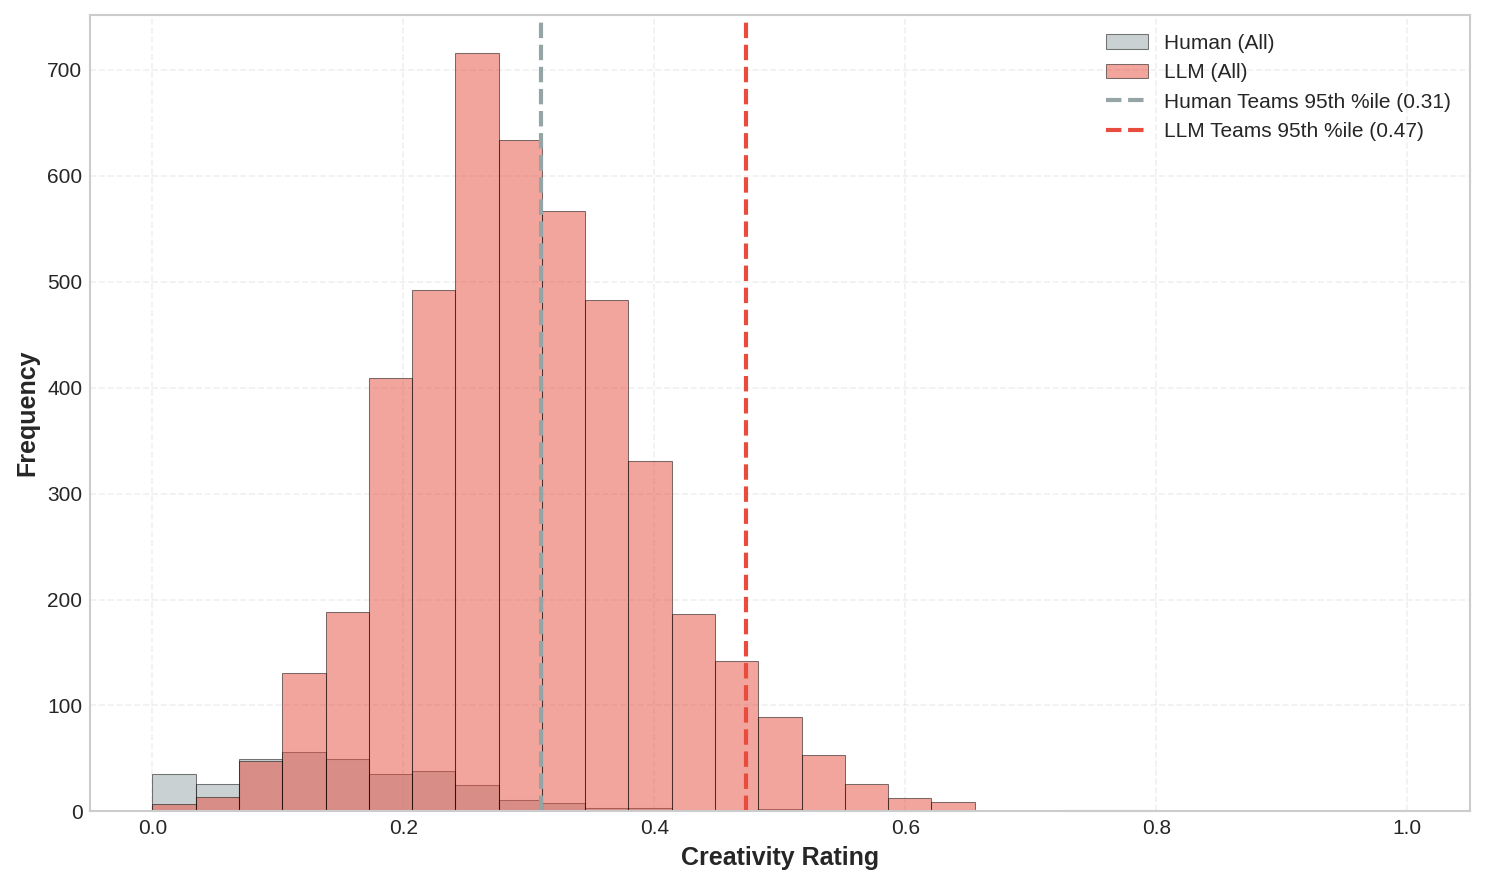

✅ Figure 1 saved as 'distribution_all_ideas.png'


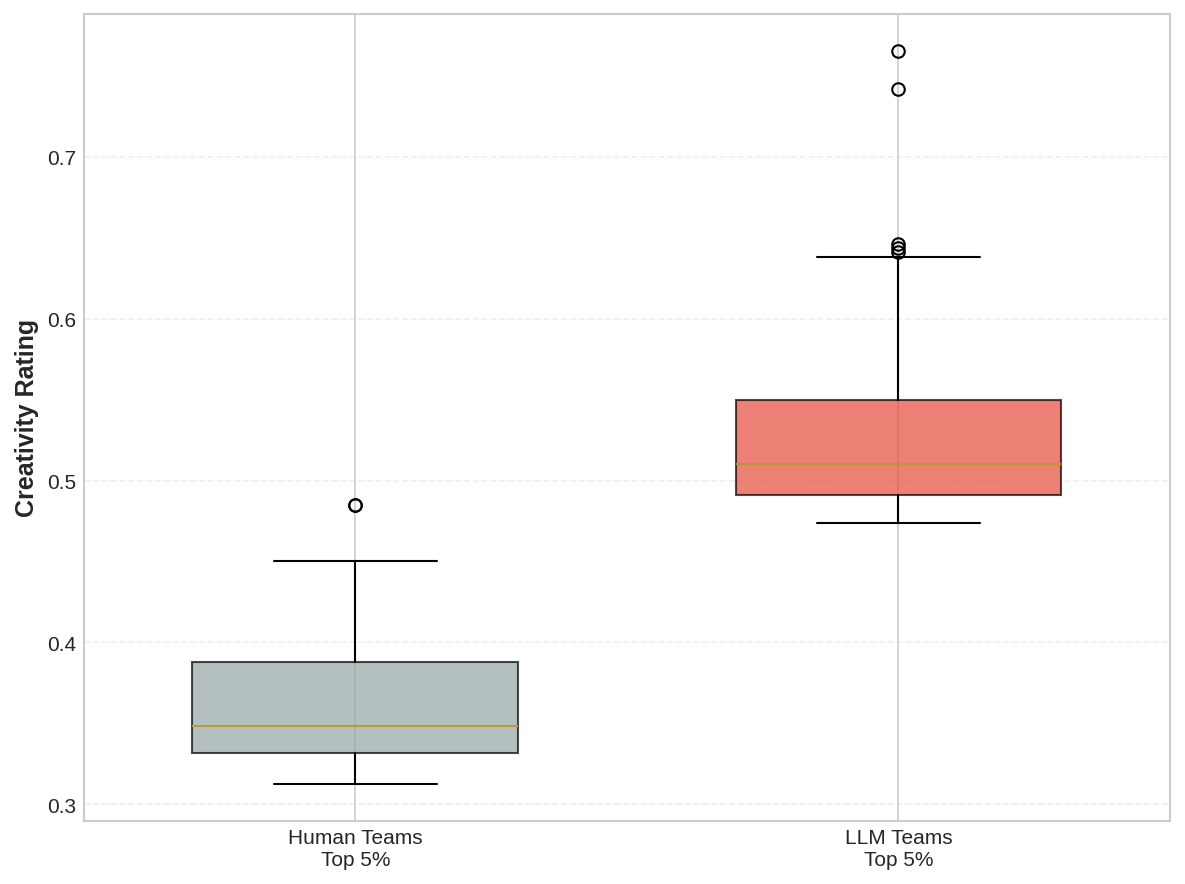

✅ Figure 2 saved as 'top5_boxplot.png'


In [80]:
import numpy as np
import pandas as pd
from scipy import stats

# ============================================================================
# BEST IDEAS ANALYSIS
# ============================================================================

print("="*80)
print("📊 BEST IDEAS ANALYSIS: LLM vs. Human")
print("="*80)

# Clean data
human_creativity = human_nominal['avg_creativity_rating'].dropna()
llm_creativity = llm_multiagent['avg_creativity_rating'].dropna()

# ============================================================================
# 1. TOP SINGLE IDEA
# ============================================================================

top_human_idea = human_creativity.max()
top_llm_idea = llm_creativity.max()

print(f"\n1️⃣ TOP SINGLE IDEA:")
print(f"   Human:  {top_human_idea:.4f}")
print(f"   LLM:    {top_llm_idea:.4f}")
print(f"   Δ:      {top_llm_idea - top_human_idea:.4f} ({((top_llm_idea - top_human_idea) / top_human_idea * 100):.1f}% improvement)")

# ============================================================================
# 2. TOP-10 IDEAS
# ============================================================================

top_10_human = human_creativity.nlargest(10)
top_10_llm = llm_creativity.nlargest(10)

top_10_human_mean = top_10_human.mean()
top_10_llm_mean = top_10_llm.mean()

# Calculate 95% CI for top-10 means
def bootstrap_ci(data, n_bootstrap=10000, confidence=0.95):
    """Bootstrap confidence interval for mean"""
    bootstrap_means = []
    for _ in range(n_bootstrap):
        sample = np.random.choice(data, size=len(data), replace=True)
        bootstrap_means.append(sample.mean())
    
    alpha = (1 - confidence) / 2
    lower = np.percentile(bootstrap_means, alpha * 100)
    upper = np.percentile(bootstrap_means, (1 - alpha) * 100)
    return lower, upper

top_10_human_ci = bootstrap_ci(top_10_human.values)
top_10_llm_ci = bootstrap_ci(top_10_llm.values)

print(f"\n2️⃣ TOP-10 IDEAS:")
print(f"   Human:  M = {top_10_human_mean:.4f}, 95% CI [{top_10_human_ci[0]:.4f}, {top_10_human_ci[1]:.4f}]")
print(f"   LLM:    M = {top_10_llm_mean:.4f}, 95% CI [{top_10_llm_ci[0]:.4f}, {top_10_llm_ci[1]:.4f}]")
print(f"   Δ:      {top_10_llm_mean - top_10_human_mean:.4f} ({((top_10_llm_mean - top_10_human_mean) / top_10_human_mean * 100):.1f}% improvement)")

# Statistical test for top-10
t_stat, p_value = stats.ttest_ind(top_10_llm, top_10_human)
print(f"   t-test: t({len(top_10_llm) + len(top_10_human) - 2}) = {t_stat:.3f}, p = {p_value:.4f}")

# ============================================================================
# 3. 95TH PERCENTILE (TOP 5%)
# ============================================================================

percentile_95_human = np.percentile(human_creativity, 95)
percentile_95_llm = np.percentile(llm_creativity, 95)

# Number of ideas in top 5%
n_top5_human = int(len(human_creativity) * 0.05)
n_top5_llm = int(len(llm_creativity) * 0.05)

print(f"\n3️⃣ 95TH PERCENTILE (TOP 5% THRESHOLD):")
print(f"   Human:  {percentile_95_human:.4f} (top {n_top5_human} ideas)")
print(f"   LLM:    {percentile_95_llm:.4f} (top {n_top5_llm} ideas)")
print(f"   Δ:      {percentile_95_llm - percentile_95_human:.4f} ({((percentile_95_llm - percentile_95_human) / percentile_95_human * 100):.1f}% higher threshold)")

# ============================================================================
# 4. DISTRIBUTION OF TOP IDEAS
# ============================================================================

# Get top 5% of each group
top_5pct_human = human_creativity.nlargest(n_top5_human)
top_5pct_llm = llm_creativity.nlargest(n_top5_llm)

print(f"\n4️⃣ TOP 5% DISTRIBUTION:")
print(f"   Human top 5%:  M = {top_5pct_human.mean():.4f}, SD = {top_5pct_human.std():.4f}")
print(f"   LLM top 5%:    M = {top_5pct_llm.mean():.4f}, SD = {top_5pct_llm.std():.4f}")

# ============================================================================
# 5. SUMMARY TABLE
# ============================================================================

summary_df = pd.DataFrame({
    'Metric': [
        'Top Single Idea',
        'Mean of Top-10',
        '95th Percentile',
        'Mean of Top 5%'
    ],
    'Human': [
        f"{top_human_idea:.3f}",
        f"{top_10_human_mean:.3f}",
        f"{percentile_95_human:.3f}",
        f"{top_5pct_human.mean():.3f}"
    ],
    'LLM': [
        f"{top_llm_idea:.3f}",
        f"{top_10_llm_mean:.3f}",
        f"{percentile_95_llm:.3f}",
        f"{top_5pct_llm.mean():.3f}"
    ],
    'Difference': [
        f"{top_llm_idea - top_human_idea:.3f}",
        f"{top_10_llm_mean - top_10_human_mean:.3f}",
        f"{percentile_95_llm - percentile_95_human:.3f}",
        f"{top_5pct_llm.mean() - top_5pct_human.mean():.3f}"
    ],
    '% Improvement': [
        f"{((top_llm_idea - top_human_idea) / top_human_idea * 100):.1f}%",
        f"{((top_10_llm_mean - top_10_human_mean) / top_10_human_mean * 100):.1f}%",
        f"{((percentile_95_llm - percentile_95_human) / percentile_95_human * 100):.1f}%",
        f"{((top_5pct_llm.mean() - top_5pct_human.mean()) / top_5pct_human.mean() * 100):.1f}%"
    ]
})

print("\n" + "="*80)
print("📋 SUMMARY TABLE")
print("="*80)
display(summary_df)

# ============================================================================
# 6. VISUALIZATION: Distribution of Top Ideas
# ============================================================================

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
bins = np.linspace(0, 1, 30)
ax.hist(human_creativity, bins=bins, alpha=0.5, label='Human (All)', 
        color='#95A5A6', edgecolor='black', linewidth=0.5)
ax.hist(llm_creativity, bins=bins, alpha=0.5, label='LLM (All)', 
        color='#E74C3C', edgecolor='black', linewidth=0.5)
# Mark top 5% thresholds
ax.axvline(percentile_95_human, color='#95A5A6', linestyle='--', linewidth=2, 
           label=f'Human Teams 95th %ile ({percentile_95_human:.2f})')
ax.axvline(percentile_95_llm, color='#E74C3C', linestyle='--', linewidth=2,
           label=f'LLM Teams 95th %ile ({percentile_95_llm:.2f})')
ax.set_xlabel('Creativity Rating', fontweight='bold', fontsize=12)
ax.set_ylabel('Frequency', fontweight='bold', fontsize=12)
#ax.set_title('Distribution of All Ideas', fontweight='bold', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('distribution_all_ideas.png', dpi=300, bbox_inches='tight')
plt.savefig('best_idea_analysis_1.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Figure 1 saved as 'distribution_all_ideas.png'")

# Panel B: Box plot of top ideas
top_ideas_data = [
    top_5pct_human.values,
    top_5pct_llm.values
]

fig, ax = plt.subplots(figsize=(8, 6))
top_ideas_data = [
    top_5pct_human.values,
    top_5pct_llm.values
]
bp = ax.boxplot(top_ideas_data, labels=['Human Teams\nTop 5%', 'LLM Teams\nTop 5%'],
                patch_artist=True, widths=0.6)
# Color the boxes
colors = ['#95A5A6', '#E74C3C']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
    patch.set_edgecolor('black')
ax.set_ylabel('Creativity Rating', fontweight='bold', fontsize=12)
#ax.set_title('Distribution of Top 5% Ideas', fontweight='bold', fontsize=14)
ax.grid(True, alpha=0.3, axis='y', linestyle='--')
plt.tight_layout()
plt.savefig('top5_boxplot.png', dpi=300, bbox_inches='tight')
plt.savefig('best_idea_analysis_2.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Figure 2 saved as 'top5_boxplot.png'")

## Top-Idea Tables

Produces Table `tab:top10_distribution` and Table `tab:top_ideas`.


In [ ]:

from pathlib import Path

def latex_escape(value):
    text = "" if pd.isna(value) else str(value)
    replacements = {
        "\\": r"\textbackslash{}",
        "&": r"\&",
        "%": r"\%",
        "$": r"\$",
        "#": r"\#",
        "_": r"\_",
        "{": r"\{",
        "}": r"\}",
        "~": r"\textasciitilde{}",
        "^": r"\textasciicircum{}",
    }
    for old, new in replacements.items():
        text = text.replace(old, new)
    return text

combined = pd.concat(
    [
        human_nominal.assign(source_group="Human"),
        llm_multiagent.assign(source_group="LLM"),
    ],
    ignore_index=True,
)

metric_specs = [
    ("Creativity", "avg_creativity_rating"),
    ("Novelty", "avg_novelty_rating"),
    ("Usefulness", "avg_usefulness_rating"),
]

rows = []
for task in task_order:
    row = {"Task": task_labels[task]}
    task_data = combined[combined["question_id"] == task]
    for metric_label, metric_col in metric_specs:
        top10 = task_data.nlargest(10, metric_col)
        row[f"{metric_label} Human"] = int((top10["source_group"] == "Human").sum())
        row[f"{metric_label} LLM"] = int((top10["source_group"] == "LLM").sum())
    rows.append(row)

top10_df = pd.DataFrame(rows)
total = {"Task": "Total"}
for metric_label, _ in metric_specs:
    total[f"{metric_label} Human"] = int(top10_df[f"{metric_label} Human"].sum())
    total[f"{metric_label} LLM"] = int(top10_df[f"{metric_label} LLM"].sum())
top10_df = pd.concat([top10_df, pd.DataFrame([total])], ignore_index=True)

top10_latex = r"""\begin{table}[h]
\centering
\caption{\textbf{Distribution of top-10 ideas per task by source.}
For each task, we identified the top 10 ideas ranked by creativity, novelty, and usefulness separately,
then counted how many came from human teams versus LLM teams.}
\label{tab:top10_distribution}
\begin{tabular}{l|cc|cc|cc}
\hline
 & \multicolumn{2}{c|}{\textbf{Creativity}} & \multicolumn{2}{c|}{\textbf{Novelty}} & \multicolumn{2}{c}{\textbf{Usefulness}} \\
\textbf{Task} & Human & LLM & Human & LLM & Human & LLM \\
\hline
"""
for _, row in top10_df.iterrows():
    top10_latex += (
        f"{latex_escape(row['Task'])} & {row['Creativity Human']} & {row['Creativity LLM']} & "
        f"{row['Novelty Human']} & {row['Novelty LLM']} & "
        f"{row['Usefulness Human']} & {row['Usefulness LLM']} \\\\\n"
    )

top10_latex += r"""\hline
\end{tabular}
\end{table}
"""
Path("table_top10_distribution.tex").write_text(top10_latex, encoding="utf-8")

top_ideas = []
for task in task_order:
    task_llm = llm_multiagent[llm_multiagent["question_id"] == task].nlargest(
        5, "avg_creativity_rating"
    )
    for rank, (_, row) in enumerate(task_llm.iterrows(), start=1):
        top_ideas.append(
            {
                "Task": task_labels[task],
                "Rank": rank,
                "Idea": row.get("final_idea", row.get("paraphrased_idea", "")),
                "Creativity": row["avg_creativity_rating"],
            }
        )
top_ideas_df = pd.DataFrame(top_ideas)
top_ideas_df.to_csv("table_top_ideas.csv", index=False)

top_ideas_latex = r"""\begin{longtable}{cp{9cm}c}
\caption{\textbf{Top 5 highest-scoring ideas per task.} All were generated by LLM teams.}
\label{tab:top_ideas} \\
\hline
\textbf{\#} & \textbf{Idea} & \textbf{Creativity} \\
\hline
\endfirsthead
\hline
\textbf{\#} & \textbf{Idea} & \textbf{Creativity} \\
\hline
\endhead
\hline
\endfoot
"""
for task, group in top_ideas_df.groupby("Task", sort=False):
    top_ideas_latex += f"\\multicolumn{{3}}{{l}}{{\\textbf{{{latex_escape(task)}}}}} \\\\\n\\hline\n"
    for _, row in group.iterrows():
        top_ideas_latex += (
            f"{int(row['Rank'])} & {latex_escape(row['Idea'])} & "
            f"{row['Creativity']:.2f} \\\\\n"
        )
    top_ideas_latex += "\\hline\n"
top_ideas_latex += r"\end{longtable}" + "\n"
Path("table_top_ideas.tex").write_text(top_ideas_latex, encoding="utf-8")

print("Saved table_top10_distribution.tex, table_top_ideas.tex, and table_top_ideas.csv")
display(top10_df)
display(top_ideas_df[["Task", "Rank", "Creativity", "Idea"]])


## Supporting Figure By Task

Produces Figure S1 / `fig:novelty_usefulness_by_task`.


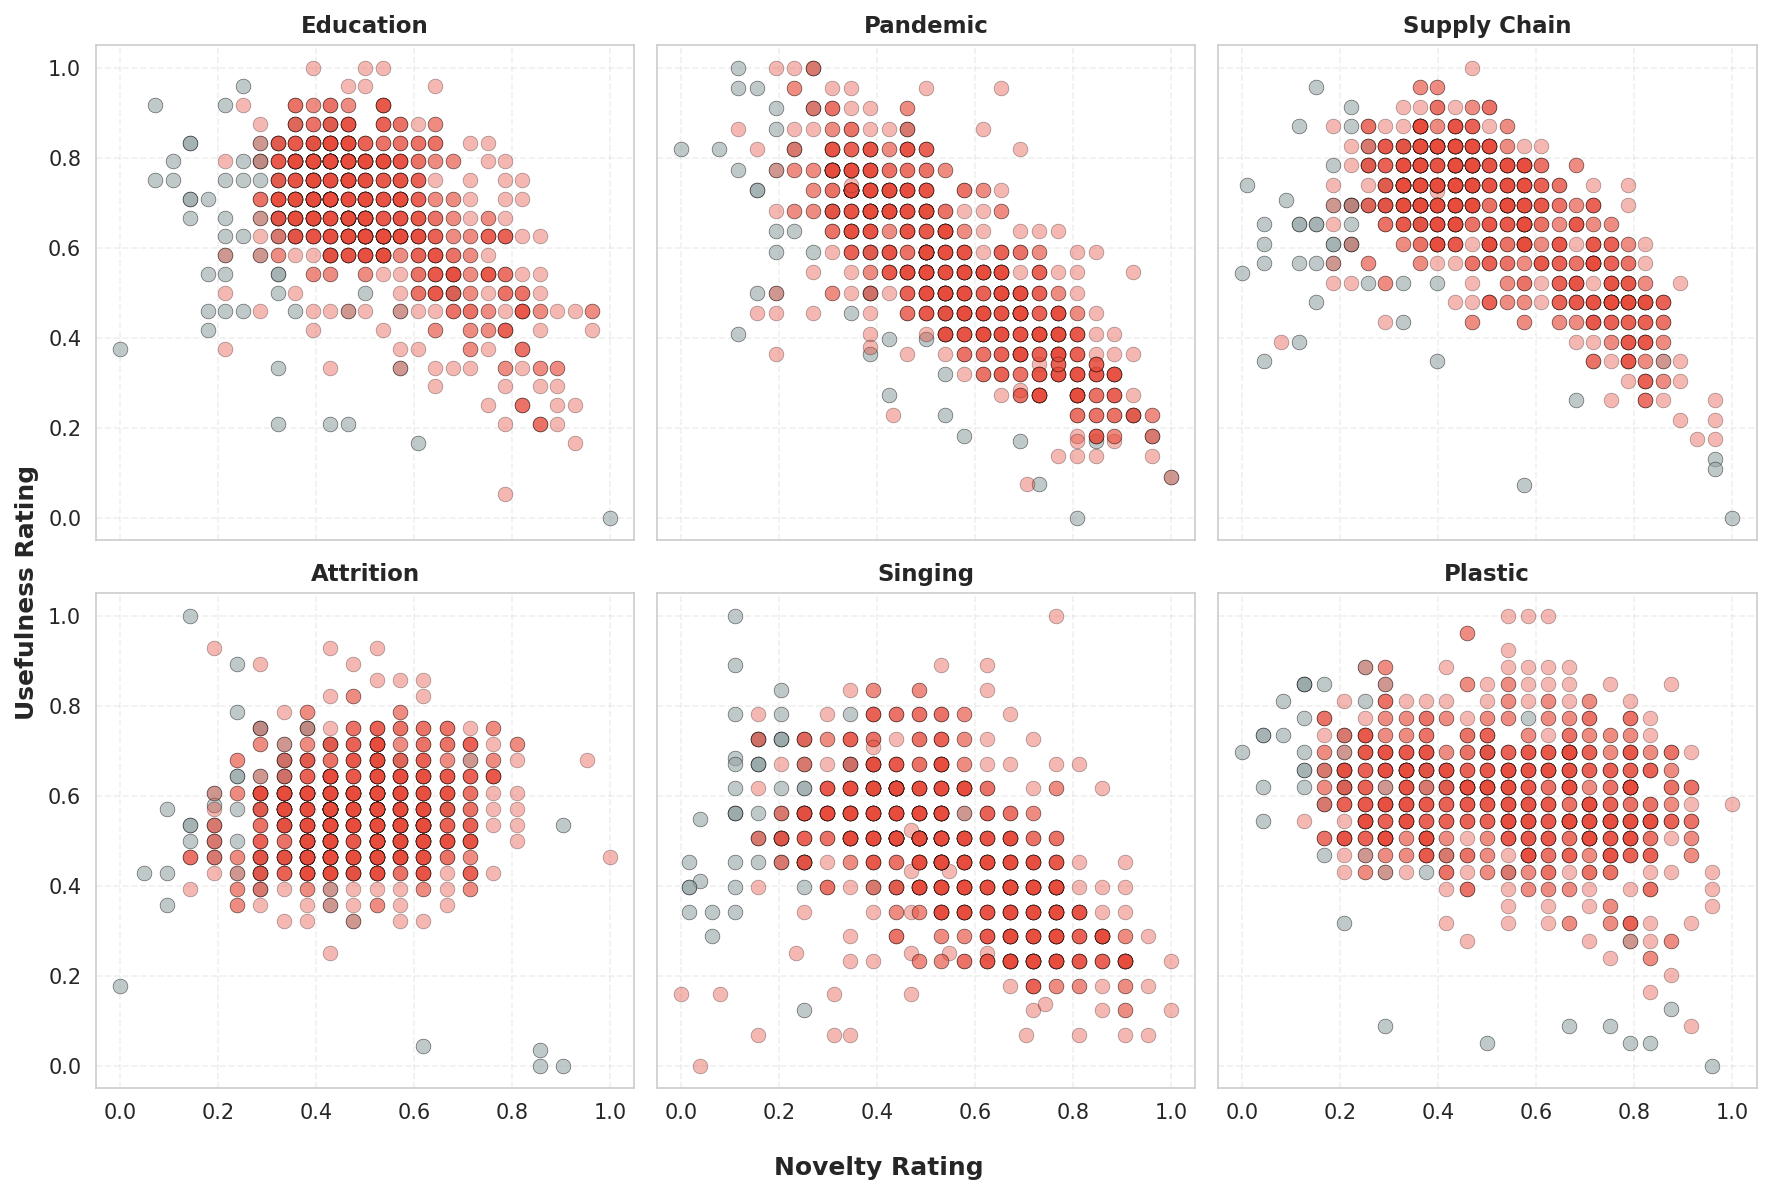

In [124]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()

for ax, task in zip(axes, task_markers.keys()):
    task_human = human_nominal[human_nominal['question_id'] == task]
    task_llm = llm_multiagent[llm_multiagent['question_id'] == task]
    
    ax.scatter(task_human['avg_novelty_rating'], task_human['avg_usefulness_rating'],
              alpha=0.6, s=50, color=COLORS['human'], edgecolors='black', linewidth=0.3)
    ax.scatter(task_llm['avg_novelty_rating'], task_llm['avg_usefulness_rating'],
              alpha=0.4, s=50, color=COLORS['llm'], edgecolors='black', linewidth=0.3)
    
    ax.set_title(task_labels[task], fontweight='bold', fontsize=11)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)

fig.supxlabel('Novelty Rating', fontweight='bold', fontsize=12)
fig.supylabel('Usefulness Rating', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('novelty_usefulness_by_task.png', dpi=300, bbox_inches='tight')
plt.show()

## Discussion Structure Effects

Produces Figure 2 / `fig:discussion_model_interaction`.


MAIN PAPER FIGURE: Creativity by Discussion Method

📊 Discussion methods: ['creative', 'instructed', 'iterative', 'none', 'open']
   GPT-4.1 single-agent: M=0.253, n=30
   o3-high single-agent: M=0.306, n=30

⚠️  KEY FINDING FOR o3-high:
   creative    : M=0.3240, n=60
   instructed  : M=0.3450, n=450
   iterative   : M=0.3428, n=120
   none        : M=0.3216, n=60
   open        : M=0.3295, n=120


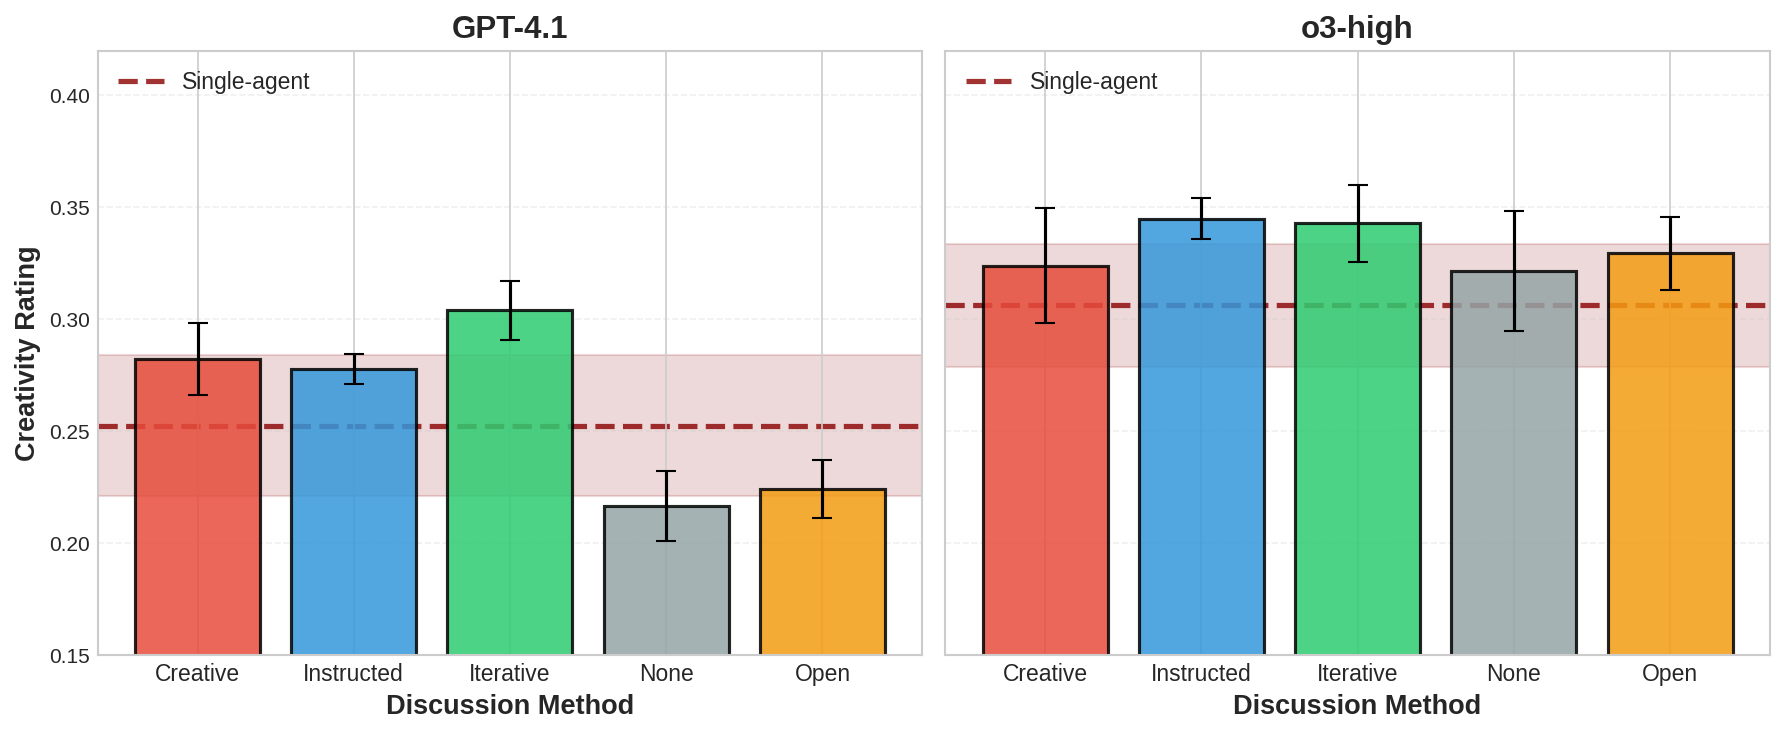


✅ Figure saved!

📊 o3-high: None vs Open
   None: M=0.3216, n=60
   Open: M=0.3295, n=120
   Difference: Δ=-0.0079
   t-test: t=-0.519, p=0.6042
   → No significant difference (discussion doesn't matter for o3!)


In [85]:
# ============================================================================
# MAIN PAPER FIGURE: Creativity by Discussion Method
# Shows: GPT-4.1 vs o3-high only, clean design
# ============================================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

print("="*80)
print("MAIN PAPER FIGURE: Creativity by Discussion Method")
print("="*80)

# Prepare data
df = llm_written_data_df.copy()

# Multi-agent data
df_multi = df[df['number_of_agents'].isin([3, 6])].copy()
df_multi = df_multi[df_multi['persona'] == 'different'].copy()
df_multi['discussion'] = df_multi['discussion'].fillna('none').astype(str).str.strip()
df_multi['model'] = df_multi['models'].fillna('Unknown').astype(str).str.strip()

# Filter to specific models
df_multi = df_multi[
    (df_multi['model'] == 'gpt-4.1') | 
    (df_multi['model'] == 'o3-high')
].copy()

df_multi['model_type'] = df_multi['model'].apply(
    lambda x: 'o3-high' if x == 'o3-high' else 'GPT-4.1'
)

# Single-agent data
df_single = df[df['number_of_agents'] == 1].copy()
df_single['model'] = df_single['models'].fillna('Unknown').astype(str).str.strip()
df_single = df_single[
    (df_single['model'] == 'gpt-4.1') | 
    (df_single['model'] == 'o3-high')
].copy()
df_single['model_type'] = df_single['model'].apply(
    lambda x: 'o3-high' if x == 'o3-high' else 'GPT-4.1'
)

# Get all discussion methods
all_methods = sorted(df_multi['discussion'].unique())
method_labels = [m.title() for m in all_methods]

print(f"\n📊 Discussion methods: {all_methods}")

# Calculate statistics
model_types = ['GPT-4.1', 'o3-high']
stats_dict = {}

for model_type in model_types:
    stats_dict[model_type] = {'means': [], 'ses': [], 'ns': []}
    
    for method in all_methods:
        subset = df_multi[
            (df_multi['model_type'] == model_type) & 
            (df_multi['discussion'] == method)
        ]['avg_creativity_rating'].dropna()
        
        stats_dict[model_type]['means'].append(subset.mean() if len(subset) > 0 else 0)
        stats_dict[model_type]['ses'].append(subset.sem() if len(subset) > 0 else 0)
        stats_dict[model_type]['ns'].append(len(subset))

# Calculate single-agent baselines
baseline_dict = {}
for model_type in model_types:
    baseline_subset = df_single[df_single['model_type'] == model_type]['avg_creativity_rating'].dropna()
    baseline_dict[model_type] = {
        'mean': baseline_subset.mean() if len(baseline_subset) > 0 else None,
        'sem': baseline_subset.sem() if len(baseline_subset) > 0 else None,
        'n': len(baseline_subset)
    }
    print(f"   {model_type} single-agent: M={baseline_dict[model_type]['mean']:.3f}, n={baseline_dict[model_type]['n']}")

# Print key comparison for o3
print(f"\n⚠️  KEY FINDING FOR o3-high:")
o3_stats = stats_dict['o3-high']
for i, method in enumerate(all_methods):
    print(f"   {method:12s}: M={o3_stats['means'][i]:.4f}, n={o3_stats['ns'][i]}")

# Define colors
method_colors = {
    'creative': '#E74C3C',
    'instructed': '#3498DB',
    'iterative': '#2ECC71',
    'none': '#95A5A6',
    'open': '#F39C12',
}
colors = [method_colors.get(m, '#999999') for m in all_methods]

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for idx, model_type in enumerate(model_types):
    ax = axes[idx]
    
    means = stats_dict[model_type]['means']
    ses = stats_dict[model_type]['ses']
    
    x = np.arange(len(all_methods))
    bars = ax.bar(x, means, yerr=[s * 1.96 for s in ses],
                  color=colors, alpha=0.85, capsize=5,
                  edgecolor='black', linewidth=1.5)
    
    # Add single-agent baseline
    baseline = baseline_dict[model_type]
    if baseline['mean'] is not None:
        ax.axhline(y=baseline['mean'], color='darkred', linestyle='--', 
                   linewidth=2.5, alpha=0.8, zorder=0,
                   label=f'Single-agent')
        
        # Shaded CI
        if baseline['sem'] is not None:
            ax.axhspan(baseline['mean'] - baseline['sem'] * 1.96, 
                      baseline['mean'] + baseline['sem'] * 1.96,
                      alpha=0.15, color='darkred', zorder=0)
    
    # Formatting
    ax.set_xlabel('Discussion Method', fontweight='bold', fontsize=13)
    if idx == 0:
        ax.set_ylabel('Creativity Rating', fontweight='bold', fontsize=13)
    
    ax.set_title(f'{model_type}', fontweight='bold', fontsize=15)
    ax.set_xticks(x)
    ax.set_xticklabels(method_labels, fontsize=11)
    ax.grid(True, alpha=0.3, axis='y', linestyle='--')
    ax.legend(fontsize=11, loc='upper left', framealpha=0.95)
    ax.set_ylim([0.15, 0.42])

#plt.suptitle('Effect of Discussion Method on Creativity', 
#             fontweight='bold', fontsize=16, y=0.99)

plt.tight_layout()
plt.savefig('main_figure_creativity_discussion_method.png', dpi=300, bbox_inches='tight')
plt.savefig('main_figure_creativity_discussion_method.pdf', bbox_inches='tight')
plt.savefig('edited_main_figure_creativity_discussion_method.pdf', bbox_inches='tight')
plt.show()

print("\n✅ Figure saved!")

# Statistical test: Is "none" really better than "open" for o3?
o3_none = df_multi[
    (df_multi['model_type'] == 'o3-high') & 
    (df_multi['discussion'] == 'none')
]['avg_creativity_rating'].dropna()

o3_open = df_multi[
    (df_multi['model_type'] == 'o3-high') & 
    (df_multi['discussion'] == 'open')
]['avg_creativity_rating'].dropna()

if len(o3_none) > 0 and len(o3_open) > 0:
    t_stat, p_val = stats.ttest_ind(o3_none, o3_open)
    print(f"\n📊 o3-high: None vs Open")
    print(f"   None: M={o3_none.mean():.4f}, n={len(o3_none)}")
    print(f"   Open: M={o3_open.mean():.4f}, n={len(o3_open)}")
    print(f"   Difference: Δ={o3_none.mean() - o3_open.mean():.4f}")
    print(f"   t-test: t={t_stat:.3f}, p={p_val:.4f}")
    
    if p_val > 0.05:
        print("   → No significant difference (discussion doesn't matter for o3!)")
    elif o3_none.mean() > o3_open.mean():
        print("   → None is significantly BETTER than open!")

## Discussion Design Tables

Produces `tab:discussion_order_effects`, `tab:round_effects`, `tab:generation_effects`, and `tab:replacement_pool`.


In [ ]:

from pathlib import Path
from scipy import stats
import statsmodels.formula.api as smf

def stars(p):
    return "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""

def fmt_coef(model, term):
    beta = model.params.get(term, np.nan)
    se = model.bse.get(term, np.nan)
    p = model.pvalues.get(term, np.nan)
    return beta, se, p, f"{beta:.4f}{stars(p)}", f"({se:.4f})", f"p={p:.3f}"

llm = llm_written_data_df.copy()
llm["question_id"] = llm["question_id"].astype(str)

# Discussion order effects
order_all = llm[
    (llm["number_of_agents"] == 3)
    & (llm["persona"] == "different")
    & (llm["discussion"] != "none")
    & llm["discussion_order_plan"].isin(["fix", "raise", "random"])
].dropna(subset=["avg_creativity_rating", "models", "discussion", "question_id"]).copy()

order_instructed = order_all[order_all["discussion"] == "instructed"].copy()

order_model_all = smf.ols(
    "avg_creativity_rating ~ C(discussion_order_plan, Treatment('random')) + C(discussion) + C(models) + C(question_id)",
    data=order_all,
).fit()
order_model_inst = smf.ols(
    "avg_creativity_rating ~ C(discussion_order_plan, Treatment('random')) + C(models) + C(question_id)",
    data=order_instructed,
).fit()

fix_all = fmt_coef(order_model_all, "C(discussion_order_plan, Treatment('random'))[T.fix]")
raise_all = fmt_coef(order_model_all, "C(discussion_order_plan, Treatment('random'))[T.raise]")
fix_inst = fmt_coef(order_model_inst, "C(discussion_order_plan, Treatment('random'))[T.fix]")
raise_inst = fmt_coef(order_model_inst, "C(discussion_order_plan, Treatment('random'))[T.raise]")

discussion_order_latex = rf"""\begin{{table}}
\caption{{Discussion order effects within discussion conditions. OLS regression testing whether discussion order affects creativity, controlling for discussion structure, model, and task. Reference category: random order. Standard errors in parentheses. $^{{*}}p<0.05$, $^{{**}}p<0.01$, $^{{***}}p<0.001$.}}
\label{{tab:discussion_order_effects}}
\begin{{tabular}}{{lcc}}
\toprule
 & All Discussion & Instructed Only \\
 & (N={len(order_all)}) & (N={len(order_instructed)}) \\
\midrule
Fix vs Random & {fix_all[3]} & {fix_inst[3]} \\
 & {fix_all[4]} & {fix_inst[4]} \\
 & {fix_all[5]} & {fix_inst[5]} \\
Raise vs Random & {raise_all[3]} & {raise_inst[3]} \\
 & {raise_all[4]} & {raise_inst[4]} \\
 & {raise_all[5]} & {raise_inst[5]} \\
\midrule
R² & {order_model_all.rsquared:.3f} & {order_model_inst.rsquared:.3f} \\
\bottomrule
\end{{tabular}}
\end{{table}}
"""
Path("table_discussion_order_effects.tex").write_text(discussion_order_latex, encoding="utf-8")

# Discussion length / round effects
round_df = llm[llm["discussion"].isin(["open", "instructed", "iterative"])].copy()
round_df["round_condition"] = round_df["condition_code"].astype(str).str.extract(r"R(30|60)(?:_M30)?")[0]
round_df.loc[
    round_df["condition_code"].astype(str).str.contains("R60_M30", na=False),
    "round_condition",
] = "60_min30"
round_df = round_df.dropna(
    subset=[
        "round_condition",
        "avg_creativity_rating",
        "discussion",
        "models",
        "persona",
        "number_of_agents",
        "question_id",
    ]
)
round_model = smf.ols(
    "avg_creativity_rating ~ C(round_condition, Treatment('30')) + C(discussion) + C(models) + C(persona) + C(number_of_agents) + C(question_id)",
    data=round_df,
).fit()
round_no = smf.ols(
    "avg_creativity_rating ~ C(discussion) + C(models) + C(persona) + C(number_of_agents) + C(question_id)",
    data=round_df,
).fit()
round_f, round_p, _ = round_model.compare_f_test(round_no)
round60 = fmt_coef(round_model, "C(round_condition, Treatment('30'))[T.60]")
round60m = fmt_coef(round_model, "C(round_condition, Treatment('30'))[T.60_min30]")
round_latex = rf"""\begin{{table}}
\caption{{Discussion length effects. OLS regression testing whether discussion length affects creativity, controlling for discussion structure, model, persona, team size, and task. Reference category: 30 rounds. Standard errors in parentheses.}}
\label{{tab:round_effects}}
\begin{{tabular}}{{lc}}
\toprule
 & Creativity \\
\midrule
60 rounds vs 30 & {round60[3]} \\
 & {round60[4]} \\
 & {round60[5]} \\
60\_min30 vs 30 & {round60m[3]} \\
 & {round60m[4]} \\
 & {round60m[5]} \\
\midrule
Omnibus test & p={round_p:.3f} \\
R² & {round_model.rsquared:.3f} \\
$\Delta$R² & {round_model.rsquared - round_no.rsquared:.3f} \\
\bottomrule
\end{{tabular}}
\end{{table}}
"""
Path("table_round_effects.tex").write_text(round_latex, encoding="utf-8")

# Generation mode effects
gen_df = llm[
    (llm["discussion"] == "none")
    & (llm["number_of_agents"] == 3)
    & (llm["persona"] == "different")
    & llm["idea_generation_plan"].isin(["interactive", "nominal"])
].dropna(subset=["avg_creativity_rating", "models", "question_id"]).copy()
gen_model = smf.ols(
    "avg_creativity_rating ~ C(idea_generation_plan, Treatment('interactive')) + C(models) + C(question_id)",
    data=gen_df,
).fit()
gen_term = fmt_coef(gen_model, "C(idea_generation_plan, Treatment('interactive'))[T.nominal]")
gen_latex = rf"""\begin{{table}}
\caption{{Idea generation mode effects in generation-only conditions. OLS regression testing whether nominal vs interactive generation affects creativity, controlling for model and task. Reference: interactive generation. Standard errors in parentheses. $^{{*}}p<0.05$, $^{{**}}p<0.01$, $^{{***}}p<0.001$.}}
\label{{tab:generation_effects}}
\begin{{tabular}}{{lc}}
\toprule
 & Creativity \\
\midrule
Nominal vs Interactive & {gen_term[3]} \\
 & {gen_term[4]} \\
 & {gen_term[5]} \\
\midrule
N & {len(gen_df)} \\
R² & {gen_model.rsquared:.3f} \\
\bottomrule
\end{{tabular}}
\end{{table}}
"""
Path("table_generation_effects.tex").write_text(gen_latex, encoding="utf-8")

# Replacement pool effects
pool_df = llm[
    (llm["number_of_agents"] == 3)
    & (llm["persona"] == "different")
    & (llm["replacement_pool_size"].isin([0, 5]))
    & (llm["condition_number"].between(31, 45))
].dropna(subset=["avg_creativity_rating", "avg_novelty_rating", "avg_usefulness_rating", "models"]).copy()
pool_df["Pool"] = np.where(pool_df["replacement_pool_size"] == 5, "Pool", "No pool")
pool_df["Model"] = pool_df["models"].replace(
    {"deepseek-ai/DeepSeek-R1, gemini-2.5-pro, o3": "Mixed"}
)

def mean_se_text(values):
    return f"{values.mean():.3f} ({values.sem():.3f})"

pool_rows = []
for model_name in ["GPT-4.1", "o3-high", "o3-low", "Mixed"]:
    model_key = "gpt-4.1" if model_name == "GPT-4.1" else model_name
    subset_model = pool_df[pool_df["Model"].eq(model_name) | pool_df["models"].eq(model_key)]
    for pool_name in ["Pool", "No pool"]:
        subset = subset_model[subset_model["Pool"] == pool_name]
        if len(subset) == 0:
            continue
        pool_rows.append(
            {
                "Model": model_name,
                "Pool": pool_name,
                "N": len(subset),
                "Creativity": mean_se_text(subset["avg_creativity_rating"]),
                "Novelty": mean_se_text(subset["avg_novelty_rating"]),
                "Usefulness": mean_se_text(subset["avg_usefulness_rating"]),
            }
        )
for pool_name in ["Pool", "No pool"]:
    subset = pool_df[pool_df["Pool"] == pool_name]
    pool_rows.append(
        {
            "Model": "Overall",
            "Pool": pool_name,
            "N": len(subset),
            "Creativity": mean_se_text(subset["avg_creativity_rating"]),
            "Novelty": mean_se_text(subset["avg_novelty_rating"]),
            "Usefulness": mean_se_text(subset["avg_usefulness_rating"]),
        }
    )
pool_summary = pd.DataFrame(pool_rows)
pool_summary.to_csv("table_replacement_pool.csv", index=False)

pool_yes = pool_df[pool_df["Pool"] == "Pool"]["avg_creativity_rating"]
pool_no = pool_df[pool_df["Pool"] == "No pool"]["avg_creativity_rating"]
t_pool, p_pool = stats.ttest_ind(pool_yes, pool_no, equal_var=False)
pooled_sd = np.sqrt(((len(pool_yes) - 1) * pool_yes.var() + (len(pool_no) - 1) * pool_no.var()) / (len(pool_yes) + len(pool_no) - 2))
d_pool = (pool_yes.mean() - pool_no.mean()) / pooled_sd

pool_latex = r"""\begin{table}[h]
\centering
\caption{\textbf{Replacement pool effects on creativity.}
Matched conditions differing only in replacement pool availability. Values show mean (standard error).}
\label{tab:replacement_pool}
\begin{tabular}{llcccc}
\toprule
\textbf{Model} & \textbf{Pool} & \textbf{N} & \textbf{Creativity} & \textbf{Novelty} & \textbf{Usefulness} \\
\midrule
"""
for _, row in pool_summary.iterrows():
    if row["Model"] == "Overall":
        pool_latex += "\\midrule\n"
    pool_latex += (
        f"{latex_escape(row['Model'])} & {latex_escape(row['Pool'])} & {row['N']} & "
        f"{row['Creativity']} & {row['Novelty']} & {row['Usefulness']} \\\\\n"
    )
pool_latex += (
    f" & $\\Delta$ & & $d={d_pool:.2f}$ & & p={p_pool:.3f} \\\\\n"
    r"""\bottomrule
\end{tabular}
\end{table}
"""
)
Path("table_replacement_pool.tex").write_text(pool_latex, encoding="utf-8")

print("Saved design/robustness tables:")
print("- table_discussion_order_effects.tex")
print("- table_round_effects.tex")
print("- table_generation_effects.tex")
print("- table_replacement_pool.tex")
display(pool_summary)


## Persona And Team Size Checks

Produces `tab:persona_effects` and `tab:team_size_llm_human`.


In [ ]:
# Prepare matched GPT-4.1 persona data used by the persona appendix table
gpt41_data = llm_written_data_df[
    (llm_written_data_df['number_of_agents'].isin([3, 6]))
    & (llm_written_data_df['models'] == 'gpt-4.1')
].copy()
gpt41_data = gpt41_data[gpt41_data['idea_generation_plan'] != 'nominal'].copy()

same_persona = gpt41_data[gpt41_data['persona'] == 'same']
orig_codes = same_persona['condition_code'].dropna().astype(str).unique().tolist()
matched_codes = set(orig_codes)
for code_value in orig_codes:
    if 'A_S' in code_value:
        matched_codes.add(code_value.replace('A_S', 'A_N', 1))
        matched_codes.add(code_value.replace('A_S', 'A_D', 1))

existing_codes = set(gpt41_data['condition_code'].dropna().astype(str).unique())
final_codes = [code_value for code_value in matched_codes if code_value in existing_codes]
matched_df = gpt41_data[gpt41_data['condition_code'].astype(str).isin(final_codes)].copy()

print(f'Matched GPT-4.1 persona rows: {len(matched_df):,}')
print(matched_df.groupby('persona').size())


In [115]:
# ============================================================================
# APPENDIX TABLE: Persona Effects (GPT-4.1, Matched Conditions)
# ============================================================================

import pandas as pd
import numpy as np
from scipy import stats

print("="*80)
print("GENERATING PERSONA TABLE FOR APPENDIX")
print("="*80)

# Use the matched_df from your earlier persona analysis
# (GPT-4.1 only, matched condition codes)

persona_conditions = ['same', 'different', 'no']
persona_labels = ['Same', 'Different', 'No']
dimensions = ['avg_creativity_rating', 'avg_novelty_rating', 'avg_usefulness_rating']
dimension_labels = ['Creativity', 'Novelty', 'Usefulness']

# Calculate statistics
persona_stats = []

for persona in persona_conditions:
    subset = matched_df[matched_df['persona'] == persona]
    
    row = {'Persona': persona_labels[persona_conditions.index(persona)]}
    
    for dim, dim_label in zip(dimensions, dimension_labels):
        values = subset[dim].dropna()
        row[f'{dim_label}_Mean'] = values.mean()
        row[f'{dim_label}_SE'] = values.sem()
        row[f'{dim_label}_N'] = len(values)
    
    persona_stats.append(row)

df_persona = pd.DataFrame(persona_stats)

# Format for display
df_persona_display = df_persona.copy()

for dim_label in dimension_labels:
    df_persona_display[dim_label] = df_persona_display.apply(
        lambda row: f"{row[f'{dim_label}_Mean']:.3f} ({row[f'{dim_label}_SE']:.3f})",
        axis=1
    )
    # Use first N (they should all be the same)
    if dim_label == 'Creativity':
        df_persona_display['N'] = df_persona_display[f'{dim_label}_N']
    
    df_persona_display = df_persona_display.drop(
        columns=[f'{dim_label}_Mean', f'{dim_label}_SE', f'{dim_label}_N']
    )

df_persona_display = df_persona_display[['Persona', 'N', 'Creativity', 'Novelty', 'Usefulness']]

print("\n" + df_persona_display.to_string(index=False))

# Pairwise t-tests
print("\n" + "="*80)
print("PAIRWISE COMPARISONS (t-tests)")
print("="*80)

for i in range(len(persona_conditions)):
    for j in range(i+1, len(persona_conditions)):
        p1, p2 = persona_conditions[i], persona_conditions[j]
        
        print(f"\n{persona_labels[i]} vs {persona_labels[j]}:")
        
        for dim, dim_label in zip(dimensions, dimension_labels):
            group1 = matched_df[matched_df['persona'] == p1][dim].dropna()
            group2 = matched_df[matched_df['persona'] == p2][dim].dropna()
            
            t_stat, p_val = stats.ttest_ind(group1, group2)
            sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
            
            print(f"  {dim_label:12s}: t={t_stat:6.3f}, p={p_val:.4f} {sig}")

# Convert to LaTeX
latex_persona = df_persona_display.to_latex(
    index=False,
    caption="Persona assignment effects on creativity, novelty, and usefulness (GPT-4.1 only, matched conditions). Values show mean (standard error). No significant differences were found in overall creativity (all pairwise comparisons p>0.05), but persona assignment shifted the balance between novelty and usefulness.",
    label="tab:persona_effects",
    escape=False,
    column_format='lrrrr'
)

with open('table_persona_effects.tex', 'w') as f:
    f.write(latex_persona)

print("\n✅ Saved: table_persona_effects.tex")

GENERATING PERSONA TABLE FOR APPENDIX

  Persona   N    Creativity       Novelty    Usefulness
     Same 478 0.258 (0.004) 0.461 (0.007) 0.587 (0.007)
Different 480 0.267 (0.004) 0.480 (0.008) 0.585 (0.007)
       No 480 0.269 (0.004) 0.541 (0.008) 0.534 (0.008)

PAIRWISE COMPARISONS (t-tests)

Same vs Different:
  Creativity  : t=-1.637, p=0.1019 ns
  Novelty     : t=-1.779, p=0.0756 ns
  Usefulness  : t= 0.269, p=0.7877 ns

Same vs No:
  Creativity  : t=-1.908, p=0.0566 ns
  Novelty     : t=-7.152, p=0.0000 ***
  Usefulness  : t= 4.980, p=0.0000 ***

Different vs No:
  Creativity  : t=-0.250, p=0.8025 ns
  Novelty     : t=-5.311, p=0.0000 ***
  Usefulness  : t= 4.683, p=0.0000 ***

✅ Saved: table_persona_effects.tex


In [120]:
# ============================================================================
# APPENDIX TABLE: Team Size Effects - LLM (GPT-4.1) vs Human Comparison
# ============================================================================

import pandas as pd
import numpy as np
from scipy import stats

print("="*80)
print("GENERATING TEAM SIZE COMPARISON TABLE (LLM vs Human)")
print("="*80)

# ============================================================================
# PART 1: GPT-4.1 Data (3 vs 6 agents, matched conditions)
# ============================================================================

df_llm = llm_written_data_df.copy()
df_llm = df_llm[
    (df_llm['models'] == 'gpt-4.1') & 
    (df_llm['persona'] == 'different')
].copy()

# Get matched conditions
six_agent_conditions = df_llm[df_llm['number_of_agents'] == 6]['condition_code'].unique()
three_agent_conditions = [cond.replace('6A', '3A', 1) for cond in six_agent_conditions]

df_llm_matched = df_llm[
    ((df_llm['number_of_agents'] == 6) & (df_llm['condition_code'].isin(six_agent_conditions))) |
    ((df_llm['number_of_agents'] == 3) & (df_llm['condition_code'].isin(three_agent_conditions)))
].copy()

print(f"GPT-4.1 matched observations: {len(df_llm_matched)}")
print(f"  3 agents: {len(df_llm_matched[df_llm_matched['number_of_agents'] == 3])}")
print(f"  6 agents: {len(df_llm_matched[df_llm_matched['number_of_agents'] == 6])}")

# ============================================================================
# PART 2: Human Data (3 vs 6 agents)
# ============================================================================

df_human = human_written_data_df.copy()
df_human = df_human[df_human['number_of_agents'].isin([3, 6])].copy()

print(f"\nHuman observations: {len(df_human)}")
print(f"  3 agents: {len(df_human[df_human['number_of_agents'] == 3])}")
print(f"  6 agents: {len(df_human[df_human['number_of_agents'] == 6])}")

# ============================================================================
# PART 3: Calculate Statistics
# ============================================================================

dimensions = ['avg_creativity_rating', 'avg_novelty_rating', 'avg_usefulness_rating']
dimension_labels = ['Creativity', 'Novelty', 'Usefulness']

results = []

for source, df_data, label in [('LLM', df_llm_matched, 'GPT-4.1'), 
                                 ('Human', df_human, 'Human')]:
    for team_size in [3, 6]:
        subset = df_data[df_data['number_of_agents'] == team_size]
        
        row = {
            'Source': label,
            'Team Size': f'{team_size} agents',
            'N': len(subset)
        }
        
        for dim, dim_label in zip(dimensions, dimension_labels):
            values = subset[dim].dropna()
            row[dim_label] = f"{values.mean():.3f} ({values.sem():.3f})"
        
        results.append(row)

df_results = pd.DataFrame(results)

print("\n" + "="*80)
print("Table: Team Size Effects - LLM vs Human")
print("="*80)
print(df_results.to_string(index=False))

# ============================================================================
# PART 4: Statistical Tests
# ============================================================================

print("\n" + "="*80)
print("STATISTICAL COMPARISONS")
print("="*80)

for source, df_data, label in [('LLM', df_llm_matched, 'GPT-4.1'), 
                                 ('Human', df_human, 'Human')]:
    print(f"\n📊 {label}:")
    
    for dim, dim_label in zip(dimensions, dimension_labels):
        group_3 = df_data[df_data['number_of_agents'] == 3][dim].dropna()
        group_6 = df_data[df_data['number_of_agents'] == 6][dim].dropna()
        
        if len(group_3) > 0 and len(group_6) > 0:
            t_stat, p_val = stats.ttest_ind(group_3, group_6)
            sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
            
            diff = group_3.mean() - group_6.mean()
            
            # Cohen's d
            pooled_std = np.sqrt(((len(group_3)-1)*group_3.std()**2 + (len(group_6)-1)*group_6.std()**2) / 
                                 (len(group_3) + len(group_6) - 2))
            cohens_d = (group_3.mean() - group_6.mean()) / pooled_std
            
            print(f"  {dim_label}:")
            print(f"    3 agents: M={group_3.mean():.4f}, n={len(group_3)}")
            print(f"    6 agents: M={group_6.mean():.4f}, n={len(group_6)}")
            print(f"    Δ={diff:.4f}, t={t_stat:.3f}, p={p_val:.4f} {sig}, d={cohens_d:.3f}")

# ============================================================================
# PART 5: Compare Process Loss Between LLM and Human
# ============================================================================

print("\n" + "="*80)
print("PROCESS LOSS COMPARISON (3-agent minus 6-agent)")
print("="*80)

for dim, dim_label in zip(dimensions, dimension_labels):
    print(f"\n{dim_label}:")
    
    # LLM process loss
    llm_3 = df_llm_matched[df_llm_matched['number_of_agents'] == 3][dim].mean()
    llm_6 = df_llm_matched[df_llm_matched['number_of_agents'] == 6][dim].mean()
    llm_loss = llm_3 - llm_6
    
    # Human process loss
    human_3 = df_human[df_human['number_of_agents'] == 3][dim].mean()
    human_6 = df_human[df_human['number_of_agents'] == 6][dim].mean()
    human_loss = human_3 - human_6
    
    print(f"  GPT-4.1 process loss: {llm_loss:.4f}")
    print(f"  Human process loss:   {human_loss:.4f}")
    print(f"  Difference:           {llm_loss - human_loss:.4f}")

# ============================================================================
# PART 6: Save LaTeX Table
# ============================================================================

latex_table = df_results.to_latex(
    index=False,
    caption="Team size effects on creativity, novelty, and usefulness for LLM (GPT-4.1) and human teams. Values show mean (standard error). Both LLM and human teams exhibit process loss, with larger teams showing lower creativity. For GPT-4.1, data restricted to matched conditions with different persona assignments.",
    label="tab:team_size_llm_human",
    escape=False,
    column_format='llrrrr'
)

with open('table_team_size_llm_human.tex', 'w') as f:
    f.write(latex_table)

print("\n✅ Saved: table_team_size_llm_human.tex")

GENERATING TEAM SIZE COMPARISON TABLE (LLM vs Human)
GPT-4.1 matched observations: 718
  3 agents: 359
  6 agents: 359

Human observations: 341
  3 agents: 224
  6 agents: 117

Table: Team Size Effects - LLM vs Human
 Source Team Size   N    Creativity       Novelty    Usefulness
GPT-4.1  3 agents 359 0.280 (0.005) 0.479 (0.008) 0.606 (0.008)
GPT-4.1  6 agents 359 0.271 (0.005) 0.511 (0.009) 0.558 (0.009)
  Human  3 agents 224 0.155 (0.006) 0.320 (0.014) 0.553 (0.014)
  Human  6 agents 117 0.142 (0.008) 0.287 (0.019) 0.600 (0.020)

STATISTICAL COMPARISONS

📊 GPT-4.1:
  Creativity:
    3 agents: M=0.2801, n=359
    6 agents: M=0.2712, n=359
    Δ=0.0089, t=1.309, p=0.1909 ns, d=0.098
  Novelty:
    3 agents: M=0.4788, n=359
    6 agents: M=0.5111, n=359
    Δ=-0.0323, t=-2.566, p=0.0105 *, d=-0.192
  Usefulness:
    3 agents: M=0.6059, n=359
    6 agents: M=0.5578, n=359
    Δ=0.0481, t=4.080, p=0.0001 ***, d=0.305

📊 Human:
  Creativity:
    3 agents: M=0.1549, n=224
    6 agents: M=0.

## Appendix Tables Used In The Paper

Produces `tab:descriptive_stats_overall`, `tab:regression_full`, `tab:discussion_effects`, `tab:descriptive_stats_discussion_methods`, and `tab:novelty_usefulness`.


In [112]:
import pandas as pd
import numpy as np

def create_pnas_appendix_table(human_df, llm_df):
    """
    Create a publication-ready table for PNAS appendix.
    Format: Mean (SD) with proper statistical formatting.
    """
    
    results = []
    
    # Helper function to format mean (SD)
    def format_stat(values):
        return f"{values.mean():.2f} ({values.std():.2f})"
    
    # Overall statistics
    results.append({
        'Task': '\\textbf{Overall}',
        'Group': 'Human',
        'N': len(human_df),
        'Creativity': format_stat(human_df['avg_creativity_rating']),
        'Novelty': format_stat(human_df['avg_novelty_rating']),
        'Usefulness': format_stat(human_df['avg_usefulness_rating'])
    })
    
    results.append({
        'Task': '',
        'Group': 'LLM',
        'N': len(llm_df),
        'Creativity': format_stat(llm_df['avg_creativity_rating']),
        'Novelty': format_stat(llm_df['avg_novelty_rating']),
        'Usefulness': format_stat(llm_df['avg_usefulness_rating'])
    })
    
    # Add separator
    results.append({
        'Task': '\\midrule',
        'Group': '',
        'N': '',
        'Creativity': '',
        'Novelty': '',
        'Usefulness': ''
    })
    
    # By-task statistics
    task_names = {
        'education_inequality': 'Education Inequality',
        'employee_attrition': 'Employee Attrition',
        'plastic_waste': 'Plastic Waste',
        'singing_shower': 'Singing in Shower',
        'sorry_pandemic': 'Sorry Pandemic',
        'supply_chain': 'Supply Chain'
    }
    
    for question_id in sorted(human_df['question_id'].unique()):
        human_task = human_df[human_df['question_id'] == question_id]
        llm_task = llm_df[llm_df['question_id'] == question_id]
        
        task_name = task_names.get(question_id, question_id.replace('_', ' ').title())
        
        results.append({
            'Task': task_name,
            'Group': 'Human',
            'N': len(human_task),
            'Creativity': format_stat(human_task['avg_creativity_rating']),
            'Novelty': format_stat(human_task['avg_novelty_rating']),
            'Usefulness': format_stat(human_task['avg_usefulness_rating'])
        })
        
        results.append({
            'Task': '',
            'Group': 'LLM',
            'N': len(llm_task),
            'Creativity': format_stat(llm_task['avg_creativity_rating']),
            'Novelty': format_stat(llm_task['avg_novelty_rating']),
            'Usefulness': format_stat(llm_task['avg_usefulness_rating'])
        })
    
    return pd.DataFrame(results)

# Create the table
appendix_table = create_pnas_appendix_table(human_written_data_df, llm_written_data_df)

# Display in notebook
print("="*80)
print("Table S1. Descriptive Statistics for Creativity Ratings by Task and Group")
print("="*80)
print("\nNote: Values shown as Mean (SD). All ratings are min-max scaled to [0, 1].")
print()
display(appendix_table)

# Generate LaTeX code
print("\n" + "="*80)
print("LATEX CODE FOR PNAS APPENDIX:")
print("="*80)

latex_code = r"""
\begin{table}[h]
\centering
\caption{Descriptive Statistics for Creativity Ratings by Task and Group}
\label{tab:descriptive_stats}
\begin{tabular}{llrrrr}
\toprule
\textbf{Task} & \textbf{Group} & \textbf{N} & \textbf{Creativity} & \textbf{Novelty} & \textbf{Usefulness} \\
\midrule
"""

# Add data rows
for idx, row in appendix_table.iterrows():
    if row['Task'] == '\\midrule':
        latex_code += "\\midrule\n"
    else:
        latex_code += f"{row['Task']} & {row['Group']} & {row['N']} & {row['Creativity']} & {row['Novelty']} & {row['Usefulness']} \\\\\n"

latex_code += r"""\bottomrule
\end{tabular}
\begin{tablenotes}
\small
\item Note: Values shown as Mean (SD). All ratings were min-max scaled to the range [0, 1] based on the full distribution of ratings. Human ideas were generated by nominal groups (3-4 participants), while LLM ideas were generated by multi-agent teams. N represents the number of ideas evaluated.
\end{tablenotes}
\end{table}
"""

print(latex_code)

# Optional: Save to file
with open('appendix_table_s1.tex', 'w') as f:
    f.write(latex_code)
print("\n✓ LaTeX code saved to 'appendix_table_s1.tex'")

# Also create a CSV for reference
appendix_table.to_csv('appendix_table_s1.csv', index=False)
print("✓ CSV saved to 'appendix_table_s1.csv'")

Table S1. Descriptive Statistics for Creativity Ratings by Task and Group

Note: Values shown as Mean (SD). All ratings are min-max scaled to [0, 1].



,Task,Group,N,Creativity,Novelty,Usefulness
0,\textbf{Overall},Human,341,0.15 (0.09),0.31 (0.21),0.57 (0.21)
1,,LLM,4720,0.30 (0.10),0.53 (0.17),0.59 (0.16)
2,\midrule,,,,,
3,Education Inequality,Human,65,0.18 (0.09),0.32 (0.17),0.62 (0.20)
4,,LLM,788,0.34 (0.08),0.52 (0.14),0.68 (0.14)
5,Employee Attrition,Human,65,0.18 (0.11),0.36 (0.20),0.53 (0.19)
6,,LLM,787,0.28 (0.10),0.49 (0.13),0.56 (0.10)
7,Plastic Waste,Human,49,0.13 (0.09),0.31 (0.25),0.56 (0.26)
8,,LLM,790,0.32 (0.13),0.54 (0.20),0.60 (0.13)
9,Singing in Shower,Human,64,0.12 (0.08),0.21 (0.13),0.57 (0.16)



LATEX CODE FOR PNAS APPENDIX:

\begin{table}[h]
\centering
\caption{Descriptive Statistics for Creativity Ratings by Task and Group}
\label{tab:descriptive_stats}
\begin{tabular}{llrrrr}
\toprule
\textbf{Task} & \textbf{Group} & \textbf{N} & \textbf{Creativity} & \textbf{Novelty} & \textbf{Usefulness} \\
\midrule
\textbf{Overall} & Human & 341 & 0.15 (0.09) & 0.31 (0.21) & 0.57 (0.21) \\
 & LLM & 4720 & 0.30 (0.10) & 0.53 (0.17) & 0.59 (0.16) \\
\midrule
Education Inequality & Human & 65 & 0.18 (0.09) & 0.32 (0.17) & 0.62 (0.20) \\
 & LLM & 788 & 0.34 (0.08) & 0.52 (0.14) & 0.68 (0.14) \\
Employee Attrition & Human & 65 & 0.18 (0.11) & 0.36 (0.20) & 0.53 (0.19) \\
 & LLM & 787 & 0.28 (0.10) & 0.49 (0.13) & 0.56 (0.10) \\
Plastic Waste & Human & 49 & 0.13 (0.09) & 0.31 (0.25) & 0.56 (0.26) \\
 & LLM & 790 & 0.32 (0.13) & 0.54 (0.20) & 0.60 (0.13) \\
Singing in Shower & Human & 64 & 0.12 (0.08) & 0.21 (0.13) & 0.57 (0.16) \\
 & LLM & 784 & 0.24 (0.08) & 0.54 (0.18) & 0.47 (0.16) \\
Sorr

In [115]:
# ============================================================================
# TOP 10 IDEAS PER TASK: Human vs LLM breakdown
# ============================================================================

print("="*80)
print("📊 TOP 10 IDEAS PER TASK: Human vs LLM")
print("="*80)

# Combine human and LLM data with source label
human_nominal_copy = human_nominal.copy()
human_nominal_copy['source'] = 'Human'
llm_multiagent_copy = llm_multiagent.copy()
llm_multiagent_copy['source'] = 'LLM'

combined_df = pd.concat([human_nominal_copy, llm_multiagent_copy], ignore_index=True)

# Get task column (adjust column name if needed)
task_col = 'question_id'  # or 'task' or 'question_content'

# Results per task
results = []

print(f"\n{'Task':<30} {'Human':>8} {'LLM':>8} {'Total':>8}")
print("-" * 60)

for task in combined_df[task_col].unique():
    task_data = combined_df[combined_df[task_col] == task].copy()
    
    # Get top 10 ideas for this task
    top_10 = task_data.nlargest(10, 'avg_creativity_rating')
    
    n_human = (top_10['source'] == 'Human').sum()
    n_llm = (top_10['source'] == 'LLM').sum()
    
    task_name = str(task)[:28]
    print(f"{task_name:<30} {n_human:>8} {n_llm:>8} {len(top_10):>8}")
    
    results.append({
        'Task': task,
        'Human': n_human,
        'LLM': n_llm,
        'Total': len(top_10)
    })

# Summary
results_df = pd.DataFrame(results)
total_human = results_df['Human'].sum()
total_llm = results_df['LLM'].sum()
total_ideas = results_df['Total'].sum()

print("-" * 60)
print(f"{'TOTAL':<30} {total_human:>8} {total_llm:>8} {total_ideas:>8}")
print(f"\nLLM share of top-10 per task: {total_llm}/{total_ideas} = {total_llm/total_ideas*100:.1f}%")

# Display detailed table
print("\n" + "="*80)
print("📋 DETAILED BREAKDOWN")
print("="*80)
display(results_df)

📊 TOP 10 IDEAS PER TASK: Human vs LLM

Task                              Human      LLM    Total
------------------------------------------------------------
education_inequality                  0       10       10
sorry_pandemic                        0       10       10
supply_chain                          0       10       10
employee_attrition                    0       10       10
singing_shower                        0       10       10
plastic_waste                         0       10       10
------------------------------------------------------------
TOTAL                                 0       60       60

LLM share of top-10 per task: 60/60 = 100.0%

📋 DETAILED BREAKDOWN


,Task,Human,LLM,Total
0,education_inequality,0,10,10
1,sorry_pandemic,0,10,10
2,supply_chain,0,10,10
3,employee_attrition,0,10,10
4,singing_shower,0,10,10
5,plastic_waste,0,10,10


In [ ]:
# ============================================================================
# COMPLETE REGRESSION ANALYSIS WITH MODEL × DISCUSSION INTERACTION
# ============================================================================

import statsmodels.formula.api as smf
from statsmodels.iolib.summary2 import summary_col
import pandas as pd
import numpy as np

print("="*80)
print("REGRESSION ANALYSIS WITH MODEL × DISCUSSION INTERACTION")
print("="*80)

# ============================================================================
# STEP 1: Data Preparation
# ============================================================================

df_regression = llm_written_data_df.copy()
df_regression = df_regression[df_regression['number_of_agents'].isin([3, 6])].copy()

print(f"\nStarting with {len(df_regression)} observations")

# Clean columns
df_regression['discussion'] = df_regression['discussion'].fillna('none').astype(str).str.strip()
df_regression['model'] = df_regression['models'].astype(str).str.strip()
df_regression['question_id'] = df_regression['question_id'].astype(str)
df_regression['number_of_agents'] = df_regression['number_of_agents'].astype(int)
df_regression['condition_code'] = df_regression['condition_code'].astype(str)
df_regression['idea_generation_plan'] = df_regression['idea_generation_plan'].fillna('none').astype(str).str.strip()

# Handle total_rounds
df_regression['total_rounds'] = pd.to_numeric(df_regression['total_rounds'], errors='coerce')
df_regression.loc[df_regression['total_rounds'] == 0, 'total_rounds'] = np.nan

# Handle discussion_order_plan
df_regression['discussion_order_plan'] = df_regression['discussion_order_plan'].fillna('not_applicable').astype(str).str.strip()
df_regression.loc[df_regression['discussion'] == 'none', 'discussion_order_plan'] = 'not_applicable'

# ============================================================================
# STEP 2: Find Common Conditions
# ============================================================================

print("\n" + "="*80)
print("FINDING COMMON CONDITIONS")
print("="*80)

n_models = df_regression['model'].nunique()
condition_model_counts = df_regression.groupby('condition_code')['model'].nunique()
common_conditions = condition_model_counts[condition_model_counts == n_models].index.tolist()

print(f"\nTotal models: {n_models}")
print(f"Common conditions: {len(common_conditions)}")

df_common = df_regression[df_regression['condition_code'].isin(common_conditions)].copy()

print(f"Observations in common conditions: {len(df_common)}")
print(f"\nDistribution by model:")
print(df_common.groupby('model').size())

# Check if number_of_agents varies
if df_common['number_of_agents'].nunique() == 1:
    print(f"\n⚠️  Number of agents constant: {df_common['number_of_agents'].iloc[0]}")
    include_agents = False
else:
    print(f"\n✅ Number of agents varies: {df_common['number_of_agents'].unique()}")
    include_agents = True

# ============================================================================
# STEP 3: Progressive Regression Models
# ============================================================================

print("\n" + "="*80)
print("PROGRESSIVE REGRESSION MODELS")
print("="*80)

# Model 1: Discussion only
model1 = smf.ols('avg_creativity_rating ~ C(discussion, Treatment("none"))', 
                 data=df_common).fit(cov_type='HC3')

# Model 2: Add model
model2 = smf.ols('avg_creativity_rating ~ C(discussion, Treatment("none")) + C(model)', 
                 data=df_common).fit(cov_type='HC3')

# Model 3: Add task
model3 = smf.ols('''avg_creativity_rating ~ 
                    C(discussion, Treatment("none")) + 
                    C(model) + 
                    C(question_id)''', 
                 data=df_common).fit(cov_type='HC3')

# Model 4: Add idea generation plan
model4 = smf.ols('''avg_creativity_rating ~ 
                    C(discussion, Treatment("none")) + 
                    C(model) + 
                    C(question_id) + 
                    C(idea_generation_plan, Treatment("none"))''', 
                 data=df_common).fit(cov_type='HC3')

# Model 5: Add discussion order plan
model5 = smf.ols('''avg_creativity_rating ~ 
                    C(discussion, Treatment("none")) + 
                    C(model) + 
                    C(question_id) + 
                    C(idea_generation_plan, Treatment("none")) +
                    C(discussion_order_plan, Treatment("not_applicable"))''', 
                 data=df_common).fit(cov_type='HC3')

# Model 6: Add MODEL × DISCUSSION INTERACTION (KEY MODEL)
model6 = smf.ols('''avg_creativity_rating ~ 
                    C(discussion, Treatment("none")) * C(model) + 
                    C(question_id) + 
                    C(idea_generation_plan, Treatment("none")) +
                    C(discussion_order_plan, Treatment("not_applicable"))''', 
                 data=df_common).fit(cov_type='HC3')

# Model 7: With rounds (subset)
df_common_with_rounds = df_common[df_common['total_rounds'].notna()].copy()

print(f"\nObservations with valid rounds: {len(df_common_with_rounds)}")

model7 = smf.ols('''avg_creativity_rating ~ 
                    C(discussion, Treatment("open")) * C(model) + 
                    C(question_id) + 
                    C(idea_generation_plan, Treatment("none")) +
                    C(discussion_order_plan, Treatment("fix")) +
                    total_rounds''', 
                 data=df_common_with_rounds).fit(cov_type='HC3')

# ============================================================================
# STEP 4: Create Summary Table
# ============================================================================

results_table = summary_col(
    [model1, model2, model3, model4, model5, model6],
    stars=True,
    float_format='%.4f',
    model_names=['(1)\nDiscuss', '(2)\n+Model', '(3)\n+Task', '(4)\n+IdeaGen', '(5)\n+Order', '(6)\n+Interact'],
    info_dict={
        'N': lambda x: f"{int(x.nobs)}",
        'R²': lambda x: f"{x.rsquared:.3f}",
        'Adj. R²': lambda x: f"{x.rsquared_adj:.3f}"
    }
)

print("\n" + results_table.as_text())

# Save
with open('regression_with_interaction.tex', 'w') as f:
    f.write(results_table.as_latex())
print("\n✅ Saved: regression_with_interaction.tex")

# ============================================================================
# STEP 5: Print Model 6 Coefficients (WITH INTERACTION)
# ============================================================================

print("\n" + "="*80)
print("MODEL 6: ALL COEFFICIENTS (WITH MODEL × DISCUSSION INTERACTION)")
print(f"N = {int(model6.nobs)}, R² = {model6.rsquared:.3f}")
print("="*80)

print("\n📊 MAIN EFFECTS:")
for param in model6.params.index:
    if ':' not in param:  # Main effects only
        coef = model6.params[param]
        pval = model6.pvalues[param]
        sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else ''
        print(f"  {param:70s}: β={coef:7.4f}, p={pval:.4f} {sig}")

print("\n📊 INTERACTION EFFECTS (Model × Discussion):")
for param in model6.params.index:
    if ':' in param and 'discussion' in param.lower():  # Interactions
        coef = model6.params[param]
        pval = model6.pvalues[param]
        sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else ''
        print(f"  {param:70s}: β={coef:7.4f}, p={pval:.4f} {sig}")

# ============================================================================
# STEP 6: Compute Discussion Effects by Model
# ============================================================================

print("\n" + "="*80)
print("DISCUSSION EFFECTS BY MODEL (Computed from Model 6)")
print("="*80)

# Reference model is deepseek, reference discussion is "none"
models = ['deepseek-ai/DeepSeek-R1, gemini-2.5-pro, o3', 'gpt-4.1', 'o3-high', 'o3-low']
discussions = ['creative', 'instructed', 'iterative', 'open']

for model_name in models:
    print(f"\n📊 {model_name}:")
    
    for disc in discussions:
        # Main effect of discussion
        main_effect_param = f'C(discussion, Treatment("none"))[T.{disc}]'
        
        if main_effect_param in model6.params.index:
            main_effect = model6.params[main_effect_param]
        else:
            main_effect = 0
        
        # Interaction effect (if not reference model)
        if model_name == 'deepseek-ai/DeepSeek-R1, gemini-2.5-pro, o3':
            # Reference model: only main effect
            total_effect = main_effect
            interaction = 0
        else:
            # Non-reference model: main + interaction
            interaction_param = f'C(discussion, Treatment("none"))[T.{disc}]:C(model)[T.{model_name}]'
            
            if interaction_param in model6.params.index:
                interaction = model6.params[interaction_param]
                interaction_pval = model6.pvalues[interaction_param]
                interaction_sig = '***' if interaction_pval < 0.001 else '**' if interaction_pval < 0.01 else '*' if interaction_pval < 0.05 else ''
            else:
                interaction = 0
                interaction_sig = ''
            
            total_effect = main_effect + interaction
        
        print(f"  {disc:12s}: Total effect = {total_effect:7.4f} (main: {main_effect:7.4f}, interaction: {interaction:7.4f} {interaction_sig if interaction != 0 else ''})")

# ============================================================================
# STEP 7: Summary
# ============================================================================

print("\n" + "="*80)
print("SUMMARY")
print("="*80)

print(f"""
✅ MAIN MODEL: Model 6 (WITH INTERACTION)
  - N = {int(model6.nobs)}
  - R² = {model6.rsquared:.3f}
  - Includes: discussion × model interaction
  - Tests whether discussion effects differ by model type

✅ ROBUSTNESS: Model 7
  - N = {int(model7.nobs)}
  - R² = {model7.rsquared:.3f}
  - Adds: total_rounds control

💡 KEY FINDING:
  The model × discussion interaction tests your hypothesis that
  discussion methods matter for GPT-4.1 but not for o3 models.
  
  Significant interactions would confirm this pattern.
""")

REGRESSION ANALYSIS WITH MODEL × DISCUSSION INTERACTION

Starting with 4541 observations

FINDING COMMON CONDITIONS

Total models: 4
Common conditions: 26
Observations in common conditions: 3224

Distribution by model:
model
deepseek-ai/DeepSeek-R1, gemini-2.5-pro, o3    797
gpt-4.1                                        809
o3-high                                        810
o3-low                                         808
dtype: int64

⚠️  Number of agents constant: 3

PROGRESSIVE REGRESSION MODELS

Observations with valid rounds: 2744


                                                                      (1)       (2)        (3)        (4)        (5)        (6)    
                                                                    Discuss    +Model     +Task     +IdeaGen    +Order   +Interact 
-----------------------------------------------------------------------------------------------------------------------------------
C(discussion, Treatment("none"))[T.creative]             

In [114]:
# ============================================================================
# GENERATE ALL APPENDIX TABLES FOR LATEX/OVERLEAF
# Tables: Regression Results, Discussion Effects, Descriptive Stats, 
#         Novelty/Usefulness Regressions
# ============================================================================

import statsmodels.formula.api as smf
from statsmodels.iolib.summary2 import summary_col
import pandas as pd
import numpy as np

# Update model labels
models = ['deepseek-ai/DeepSeek-R1, gemini-2.5-pro, o3', 'gpt-4.1', 'o3-high', 'o3-low']
model_labels = ['Mixed', 'GPT-4.1', 'o3-high', 'o3-low']

# ============================================================================
# TABLE 1: Full Regression Results (Models 1-6)
# ============================================================================

print("="*80)
print("GENERATING TABLE 1: Full Regression Results")
print("="*80)

# Create summary table (using models 1-6 from previous code)
table1 = summary_col(
    [model1, model2, model3, model4, model5, model6],
    stars=True,
    float_format='%.4f',
    model_names=['(1)', '(2)', '(3)', '(4)', '(5)', '(6)'],
    info_dict={
        'N': lambda x: f"{int(x.nobs)}",
        'R²': lambda x: f"{x.rsquared:.3f}",
        'Adj. R²': lambda x: f"{x.rsquared_adj:.3f}"
    }
)

# Save LaTeX
with open('table1_regression_full.tex', 'w') as f:
    f.write(table1.as_latex())

print("✅ Saved: table1_regression_full.tex")

# ============================================================================
# TABLE 2: Discussion Effects Summary (Regression Coefficients)
# ============================================================================

print("\n" + "="*80)
print("GENERATING TABLE 2: Discussion Effects by Model")
print("="*80)

discussions = ['creative', 'instructed', 'iterative', 'open']
discussion_labels = ['Creative', 'Instructed', 'Iterative', 'Open']

# Extract effects from Model 6
summary_data = []

for i, model_name in enumerate(models):
    for j, disc in enumerate(discussions):
        # Main effect
        main_effect_param = f'C(discussion, Treatment("none"))[T.{disc}]'
        if main_effect_param in model6.params.index:
            main_effect = model6.params[main_effect_param]
            main_pval = model6.pvalues[main_effect_param]
        else:
            main_effect = 0
            main_pval = 1
        
        # Interaction effect
        if model_name == 'deepseek-ai/DeepSeek-R1, gemini-2.5-pro, o3':
            interaction = 0
            interaction_pval = 1
            total_pval = main_pval
        else:
            interaction_param = f'C(discussion, Treatment("none"))[T.{disc}]:C(model)[T.{model_name}]'
            if interaction_param in model6.params.index:
                interaction = model6.params[interaction_param]
                interaction_pval = model6.pvalues[interaction_param]
                total_pval = interaction_pval  # For non-reference models, test the interaction
            else:
                interaction = 0
                interaction_pval = 1
                total_pval = 1
        
        total_effect = main_effect + interaction
        
        # Determine significance stars
        if total_pval < 0.001:
            sig = '***'
        elif total_pval < 0.01:
            sig = '**'
        elif total_pval < 0.05:
            sig = '*'
        else:
            sig = ''
        
        summary_data.append({
            'Model': model_labels[i],
            'Discussion': discussion_labels[j],
            'Effect': total_effect,
            'SE': model6.bse[interaction_param] if interaction_param in model6.bse.index else model6.bse[main_effect_param],
            'Sig': sig
        })

df_table2 = pd.DataFrame(summary_data)

# Create formatted strings
df_table2['Formatted'] = df_table2.apply(
    lambda row: f"{row['Effect']:.4f}{row['Sig']}", axis=1
)

# Pivot to wide format
df_table2_wide = df_table2.pivot(index='Discussion', columns='Model', values='Formatted')
df_table2_wide = df_table2_wide[model_labels]  # Reorder columns

# Convert to LaTeX
latex_table2 = df_table2_wide.to_latex(
    escape=False,
    caption="Discussion method effects on creativity by model type (vs. no discussion baseline). Values show estimated effects from Model 6 with model $\\times$ discussion interaction. For Mixed model, coefficients represent main effects; for other models, coefficients represent total effects (main + interaction). Standard errors in parentheses. $^{*}p<0.05$, $^{**}p<0.01$, $^{***}p<0.001$.",
    label="tab:discussion_effects"
)

with open('table2_discussion_effects.tex', 'w') as f:
    f.write(latex_table2)

print("✅ Saved: table2_discussion_effects.tex")

# ============================================================================
# TABLE 3: Descriptive Statistics (Creativity, Novelty, Usefulness)
# ============================================================================

print("\n" + "="*80)
print("GENERATING TABLE 3: Descriptive Statistics")
print("="*80)

discussions_full = ['none', 'creative', 'instructed', 'iterative', 'open']
discussion_labels_full = ['None', 'Creative', 'Instructed', 'Iterative', 'Open']

dimensions = ['avg_creativity_rating', 'avg_novelty_rating', 'avg_usefulness_rating']
dimension_labels = ['Creativity', 'Novelty', 'Usefulness']

summary_rows = []

for i, model_name in enumerate(models):
    for j, disc in enumerate(discussions_full):
        subset = df_common[
            (df_common['model'] == model_name) & 
            (df_common['discussion'] == disc)
        ]
        
        if len(subset) == 0:
            continue
        
        row = {
            'Model': model_labels[i],
            'Discussion': discussion_labels_full[j],
            'N': len(subset)
        }
        
        for dim, dim_label in zip(dimensions, dimension_labels):
            values = subset[dim].dropna()
            if len(values) > 0:
                row[dim_label] = f"{values.mean():.3f} ({values.sem():.3f})"
            else:
                row[dim_label] = '—'
        
        summary_rows.append(row)

df_table3 = pd.DataFrame(summary_rows)

# Sort
df_table3['Model_Order'] = df_table3['Model'].map({
    'GPT-4.1': 0, 'o3-high': 1, 'o3-low': 2, 'Mixed': 3
})
df_table3['Discussion_Order'] = df_table3['Discussion'].map({
    'None': 0, 'Creative': 1, 'Instructed': 2, 'Iterative': 3, 'Open': 4
})
df_table3 = df_table3.sort_values(['Model_Order', 'Discussion_Order'])
df_table3 = df_table3.drop(columns=['Model_Order', 'Discussion_Order'])

# Convert to LaTeX
latex_table3 = df_table3.to_latex(
    index=False,
    caption="Descriptive statistics for creativity, novelty, and usefulness by model type and discussion method. Values show mean (standard error). Data restricted to conditions common across all models.",
    label="tab:descriptive_stats_discussion_methods",
    escape=False,
    column_format='llrrrr'
)

with open('table3_descriptive_stats.tex', 'w') as f:
    f.write(latex_table3)

print("✅ Saved: table3_descriptive_stats.tex")

# ============================================================================
# TABLE 4: Separate Regressions for Novelty and Usefulness
# ============================================================================

print("\n" + "="*80)
print("GENERATING TABLE 4: Novelty and Usefulness Regressions")
print("="*80)

# Run regressions for novelty and usefulness with same specification as Model 6
formula_interaction = '''OUTCOME ~ 
                         C(discussion, Treatment("none")) * C(model) + 
                         C(question_id) + 
                         C(idea_generation_plan, Treatment("none")) +
                         C(discussion_order_plan, Treatment("not_applicable"))'''

# Novelty regression
formula_novelty = formula_interaction.replace('OUTCOME', 'avg_novelty_rating')
model_novelty = smf.ols(formula_novelty, data=df_common).fit(cov_type='HC3')

# Usefulness regression
formula_usefulness = formula_interaction.replace('OUTCOME', 'avg_usefulness_rating')
model_usefulness = smf.ols(formula_usefulness, data=df_common).fit(cov_type='HC3')

# Create summary table
table4 = summary_col(
    [model6, model_novelty, model_usefulness],
    stars=True,
    float_format='%.4f',
    model_names=['Creativity', 'Novelty', 'Usefulness'],
    info_dict={
        'N': lambda x: f"{int(x.nobs)}",
        'R²': lambda x: f"{x.rsquared:.3f}",
        'Adj. R²': lambda x: f"{x.rsquared_adj:.3f}"
    }
)

# Save LaTeX
with open('table4_novelty_usefulness_regressions.tex', 'w') as f:
    f.write(table4.as_latex())
with open('table_novelty_usefulness.tex', 'w') as f:
    f.write(table4.as_latex())

print("✅ Saved: table4_novelty_usefulness_regressions.tex")

# ============================================================================
# SUMMARY
# ============================================================================

print("\n" + "="*80)
print("ALL TABLES GENERATED!")
print("="*80)
print("""
✅ table1_regression_full.tex
   - Full regression results (Models 1-6)
   - Shows progressive addition of controls
   
✅ table2_discussion_effects.tex
   - Discussion effects by model (from Model 6)
   - Clean summary of key findings
   
✅ table3_descriptive_stats.tex
   - Means and SEs for creativity, novelty, usefulness
   - All model × discussion combinations
   
✅ table4_novelty_usefulness_regressions.tex
   - Separate regressions for novelty and usefulness
   - Shows trade-off mechanism

📋 TO USE IN OVERLEAF:
   1. Upload all .tex files to your Overleaf project
   2. In your main document, use: \\input{table1_regression_full.tex}
   3. Adjust captions and labels as needed
   4. Add notes about reference categories in table notes
""")

# Print sample LaTeX code for including tables
print("\n" + "="*80)
print("SAMPLE LATEX CODE FOR YOUR APPENDIX:")
print("="*80)
print(r"""
\section{Supplementary Tables}

\subsection{Regression Results}
\input{table1_regression_full.tex}

\subsection{Discussion Method Effects by Model}
\input{table2_discussion_effects.tex}

\subsection{Descriptive Statistics}
\input{table3_descriptive_stats.tex}

\subsection{Novelty and Usefulness Regressions}
\input{table4_novelty_usefulness_regressions.tex}
""")

GENERATING TABLE 1: Full Regression Results
✅ Saved: table1_regression_full.tex

GENERATING TABLE 2: Discussion Effects by Model
✅ Saved: table2_discussion_effects.tex

GENERATING TABLE 3: Descriptive Statistics
✅ Saved: table3_descriptive_stats.tex

GENERATING TABLE 4: Novelty and Usefulness Regressions
✅ Saved: table4_novelty_usefulness_regressions.tex

ALL TABLES GENERATED!

✅ table1_regression_full.tex
   - Full regression results (Models 1-6)
   - Shows progressive addition of controls
   
✅ table2_discussion_effects.tex
   - Discussion effects by model (from Model 6)
   - Clean summary of key findings
   
✅ table3_descriptive_stats.tex
   - Means and SEs for creativity, novelty, usefulness
   - All model × discussion combinations
   
✅ table4_novelty_usefulness_regressions.tex
   - Separate regressions for novelty and usefulness
   - Shows trade-off mechanism

📋 TO USE IN OVERLEAF:
   1. Upload all .tex files to your Overleaf project
   2. In your main document, use: \input{table